# Investigate the best value for a cut on the Double charm BDT_all

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)
signal: 12528
18: 138749
19: 136309
20: 58879


In [2]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle

## Loading the BDTs

In [3]:
#model = xgb.XGBClassifier()
#model.load_model("../model_18.json")
import joblib
bdt_18 = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_18_200.pkl")
bdt_19 = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_19_200.pkl")
bdt_20 = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_20_200.pkl")
bdt_all = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_all_200.pkl")

## Loading the data

In [4]:
dfall = load_complete_df()
dfall.shape

(649799, 36)

In [5]:
# We check the BDTs on eeventIndex 1 as they were traineds on eventIndex 0
df = dfall.query("eventIndex == 1")
df.shape

(324816, 36)

## Added columns with the output of the BDTs for categories 18, 19, 20

In [7]:
#df['category']
#mygroupby(df, 'category')
df = df.copy()
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
pred = bdt_18.predict_proba(df[train_columns])
df['bdt_18'] = pred[:,1]
pred = bdt_19.predict_proba(df[train_columns])
df['bdt_19'] = pred[:,1]
pred = bdt_20.predict_proba(df[train_columns])
df['bdt_20'] = pred[:,1]
pred = bdt_all.predict_proba(df[train_columns])
df['bdt_all'] = pred[:,1]


## Checking the ROC curves for the BDTs agains all candidates

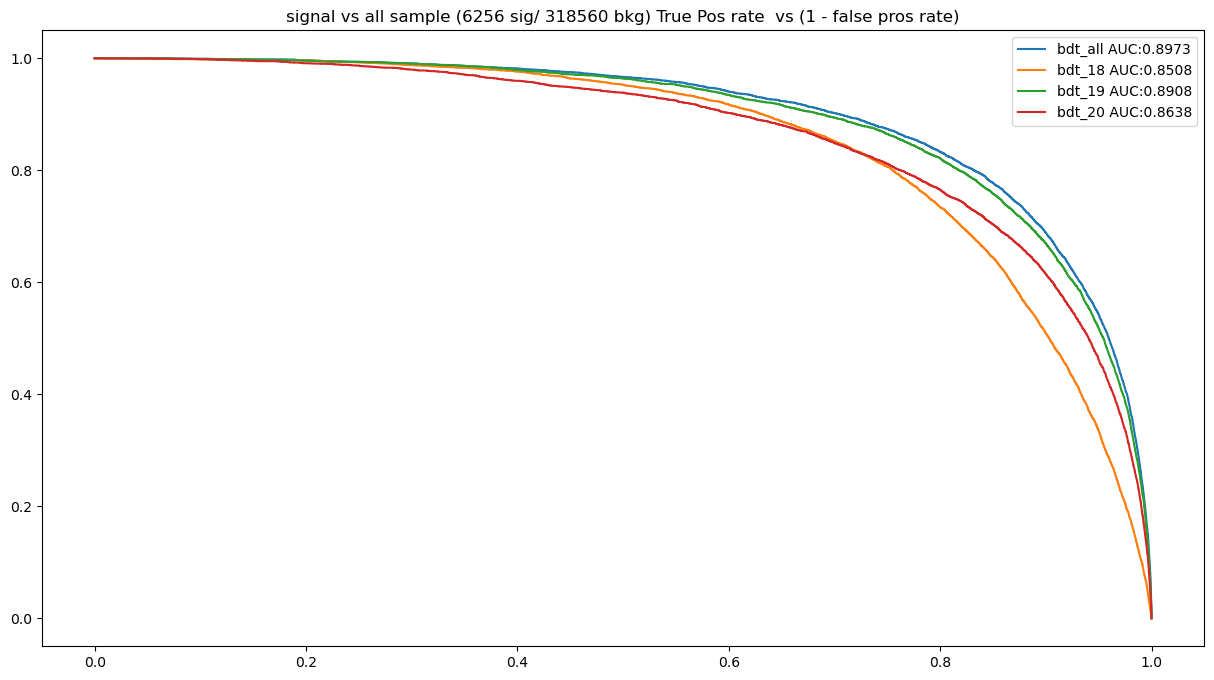

In [8]:
def plot_roc(df, proba_column):
    fpr, tpr, _ = roc_curve(df['category'] == 24, df[proba_column])
    roc_auc = auc(fpr, tpr)
    plt.plot(1 - fpr, tpr, label=f"{proba_column} AUC:{roc_auc:.4f}")

def plot_all(df, title):
    plot_roc(df, 'bdt_all')
    plot_roc(df, 'bdt_18')
    plot_roc(df, 'bdt_19')
    plot_roc(df, 'bdt_20')
    plt.title(f"{title} ({len(df.query('category == 24'))} sig/ {len(df.query('category != 24'))} bkg) True Pos rate  vs (1 - false pros rate)")
    plt.legend();
    
plot_all(df, "signal vs all sample")

### BDT response for the samples

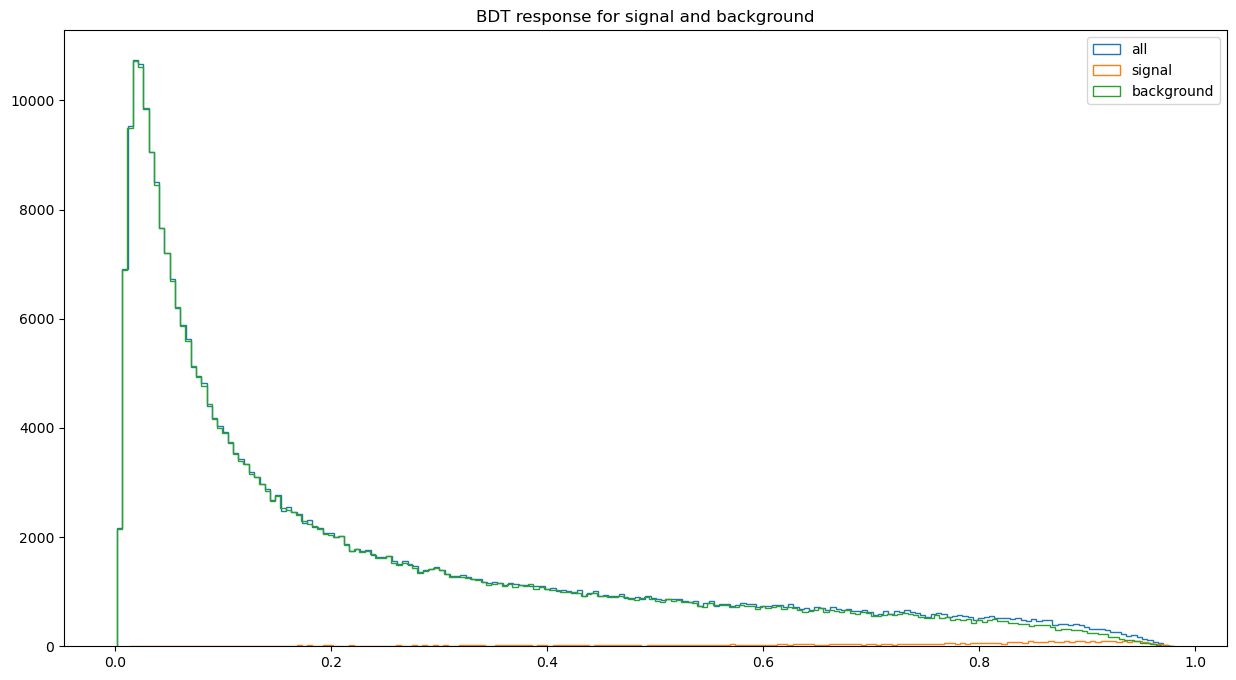

In [9]:
plt.hist(df['bdt_all'], bins=200, histtype='step', label='all')
plt.hist(df[df['signal'] == 1]['bdt_all'], bins=200, histtype='step', label='signal')
plt.hist(df[df['signal'] == 0]['bdt_all'], bins=200, histtype='step', label='background');
plt.legend()
plt.title("BDT response for signal and background");

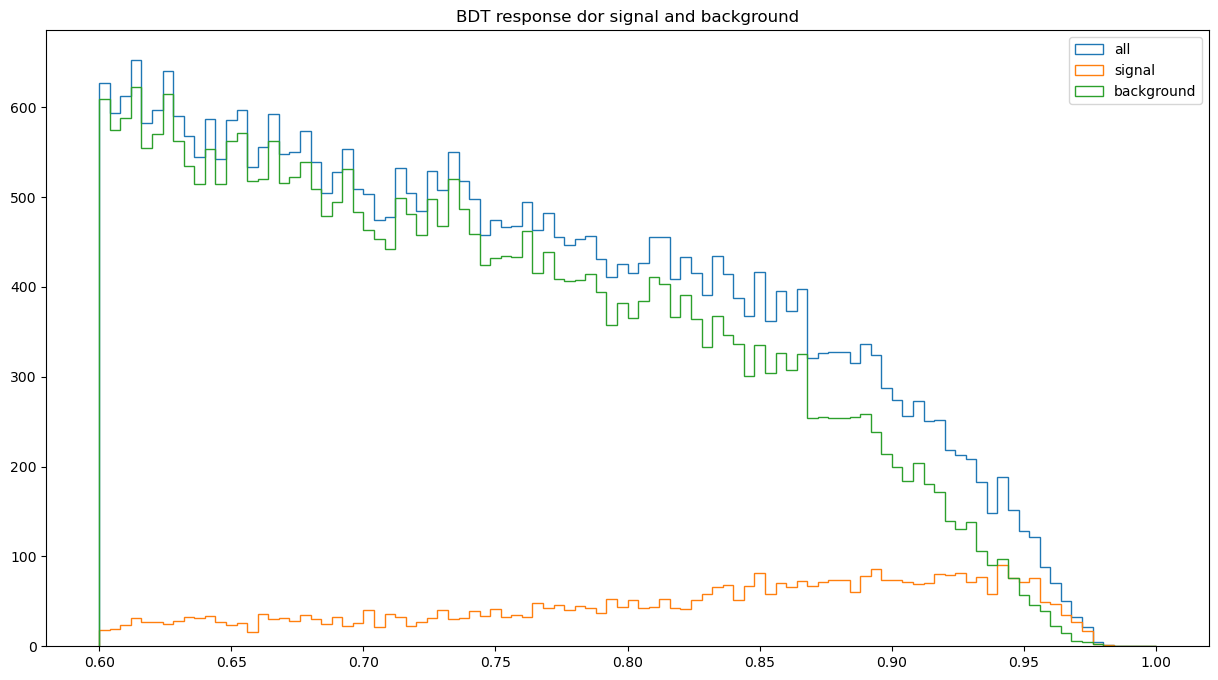

In [10]:
nbins=100
myrange=[0.6, 1.0]
plt.hist(df['bdt_all'], bins=nbins, histtype='step', label='all', range=myrange, )
plt.hist(df[df['signal'] == 1]['bdt_all'], bins=nbins, range=myrange, histtype='step', label='signal')
plt.hist(df[df['signal'] == 0]['bdt_all'], bins=nbins, histtype='step', label='background', range=myrange );
plt.legend()
plt.title("BDT response dor signal and background");

In [11]:
cuts = np.arange(0.0, 1.0, 0.005)
nb_total = len(df)
nb_sig = len(df[df['signal']==1])
nb_bkg = len(df[df['signal']==0])
print(f"Total: {nb_total}, sig:{nb_sig}, bkg:{nb_bkg}, ratio: {nb_bkg/nb_sig:.2f}")
results = []
for c in cuts:
    dftmp = df.query(f"bdt_all > {c}")
    nbs = len(dftmp.query("signal == 1"))
    nbb = len(dftmp.query("signal == 0"))
    results.append((c, nbs, nbb))
dfresult = pd.DataFrame(results, columns=["cut", "sig", "bkg"])
dfresult["bkg/sig"] = dfresult["bkg"] / dfresult["sig"]
dfresult["fom1"] = dfresult["sig"] / np.sqrt(dfresult["sig"] + dfresult["bkg"])
dfresult["sig_eff"] = dfresult["sig"] / nb_sig
dfresult["bkg_eff"] = dfresult["bkg"] / nb_bkg


Total: 324816, sig:6257, bkg:318559, ratio: 50.91


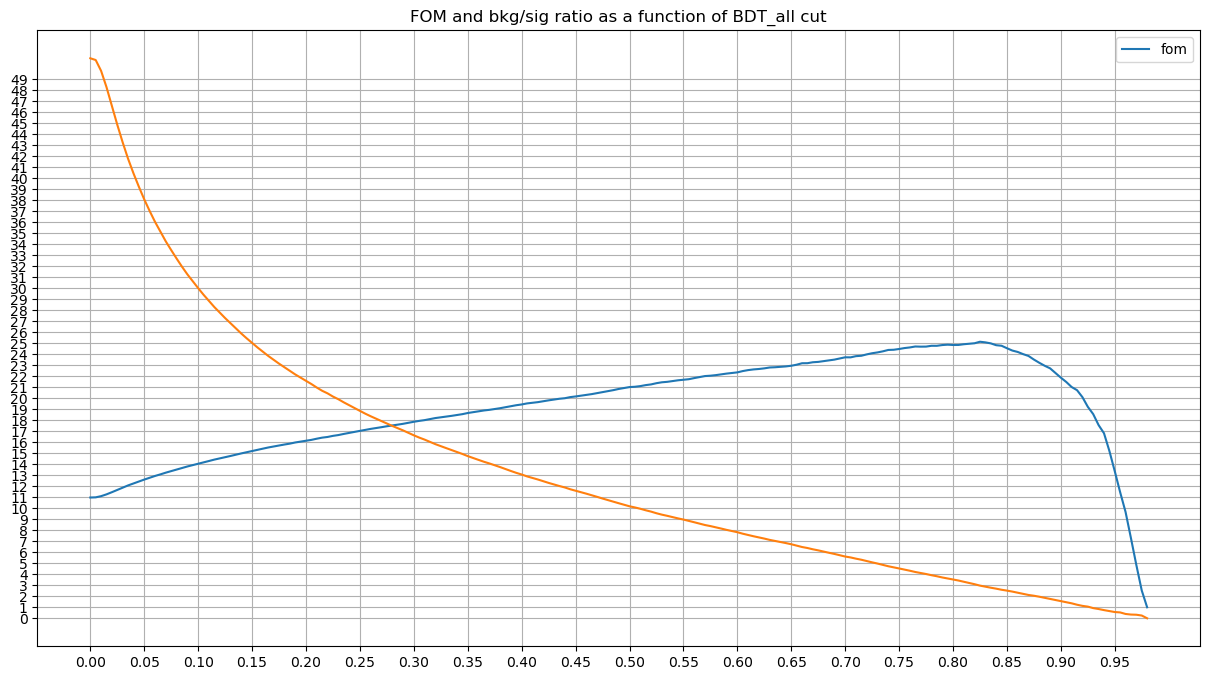

In [12]:
plt.plot(dfresult["cut"], dfresult["fom1"], label="fom");
plt.plot(dfresult["cut"], dfresult["bkg/sig"]);
# ax = plt.gca()
# ax.set_ylim([0, 100])
plt.xticks(np.arange(0, 1, 0.05))
plt.yticks(np.arange(0, 50, 1))
plt.grid()
plt.legend()
plt.title("FOM and bkg/sig ratio as a function of BDT_all cut");

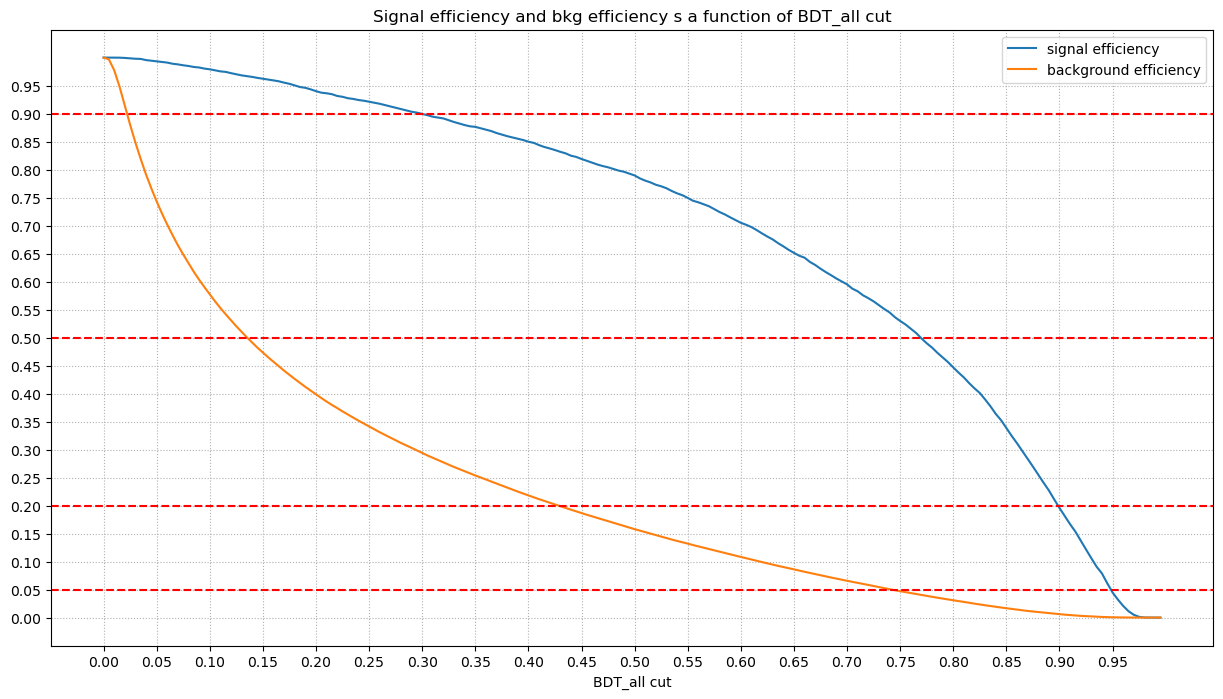

In [13]:
plt.plot(dfresult["cut"], dfresult["sig_eff"], label="signal efficiency");
plt.plot(dfresult["cut"], dfresult["bkg_eff"], label="background efficiency");
plt.xlabel("BDT_all cut")
plt.legend()

plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.axhline(y = 0.5, color = 'r', linestyle = '--')
plt.axhline(y = 0.2, color = 'r', linestyle = '--')
plt.axhline(y = 0.05, color = 'r', linestyle = '--')
plt.xticks(np.arange(0, 1, 0.05))
plt.yticks(np.arange(0, 1, 0.05))
plt.grid( linestyle=":", )
plt.title("Signal efficiency and bkg efficiency s a function of BDT_all cut");

We start exploring 2 cuts:

  - *CUT1*:  BDT_all > 0.75, i.e. We keep 50% of signal, but only 5% of background (ration bkg/sig of ~5)
  - *CUT2*: BDT_all > 0.35, we keep 90% of signal and 50% of background (ration bkg/sig of ~ 18)

## Checking CUT1 i.e. BDT_all > 0.75

In [14]:
dfcut1 = df.query("bdt_all > 0.75")

In [15]:
c = mygroupby(dfcut1, 'category')
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c

,category,count,Percentage,cumulative %,name
0,19,3916,21.370880,21.370880,Xc_signal_Ypis_displaced_fromB0_fromDp
1,24,3314,18.085571,39.456451,Xc_signal_Ypis_displaced_fromBs_fromTau
2,22,2005,10.941934,50.398385,Xc_signal_Ypis_displaced_fromBs_fromDp
3,0,1654,9.026413,59.424798,Xc_background
4,14,1569,8.562541,67.987339,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB
5,20,1277,6.969002,74.956341,Xc_signal_Ypis_displaced_fromBp_fromD0
6,18,1133,6.183148,81.139489,Xc_signal_Ypis_displaced_fromBs_fromDs
7,23,885,4.829731,85.969221,Xc_signal_Ypis_displaced_fromBp_fromDp
8,7,721,3.934730,89.903951,Xc_signal_Ypis_nomatch_doubleCharm
9,25,326,1.779088,91.683039,Xc_signal_Ypis_displaced_fromB0_fromD0


There are 17 categories represented by more than 100 candidates

In [93]:
shown_number=17

shown_categs = list(c.head(shown_number)['category'])
datasets = [ dfcut1.query(f"category == {c}") for c in shown_categs ]
datasets.append( dfcut1.query(f"category not in {shown_categs}"))
datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
datasets_names.append("others")
                

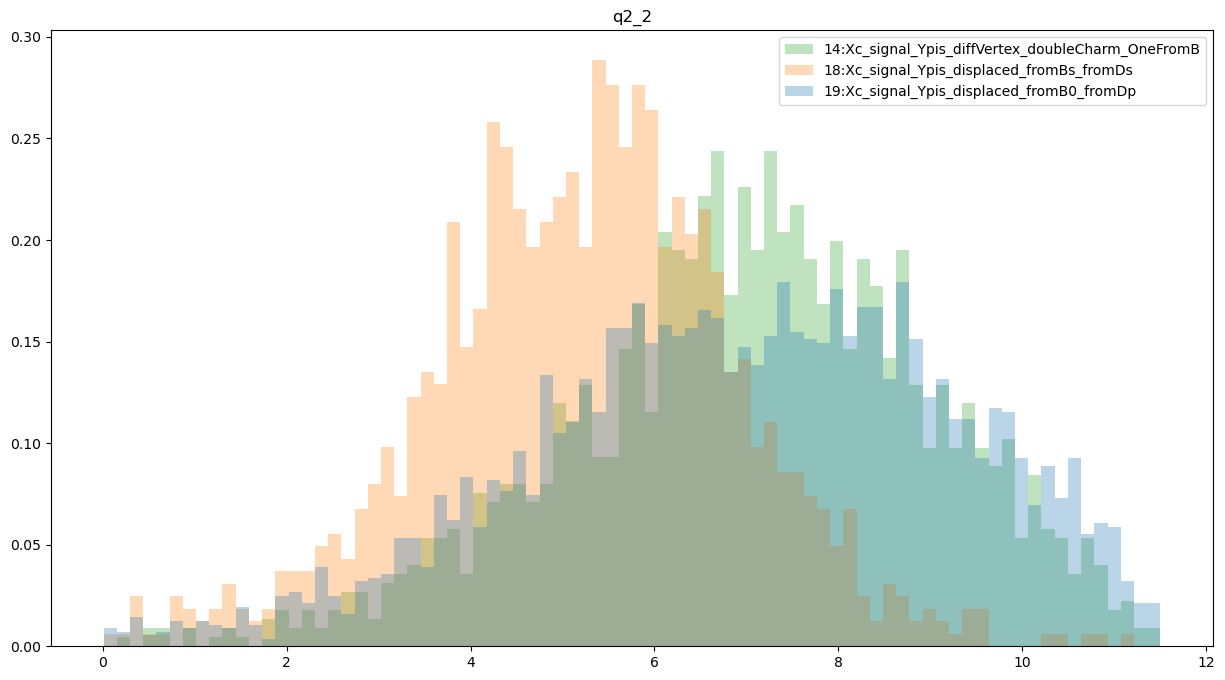

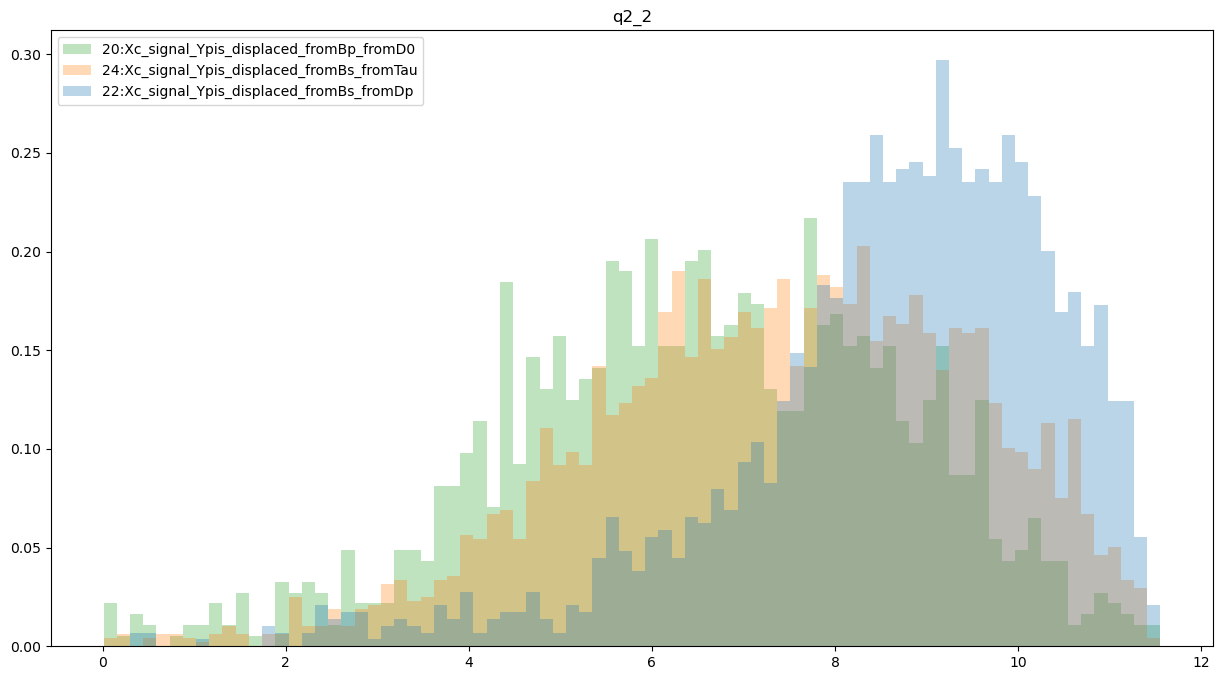

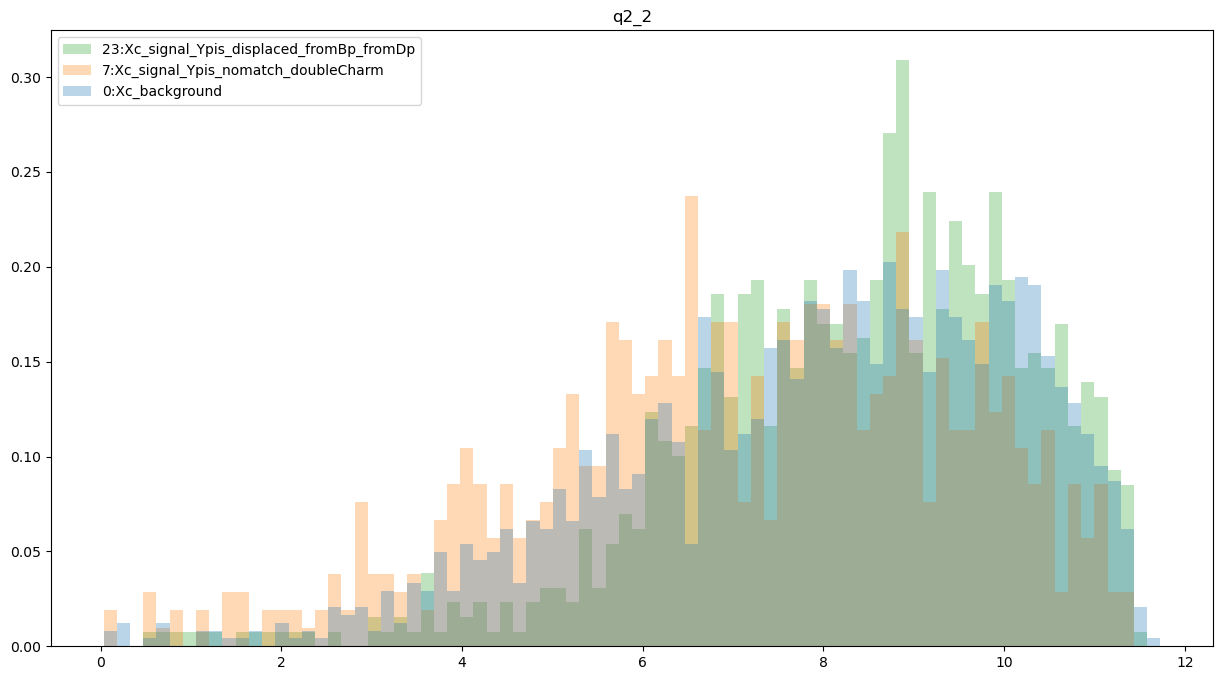

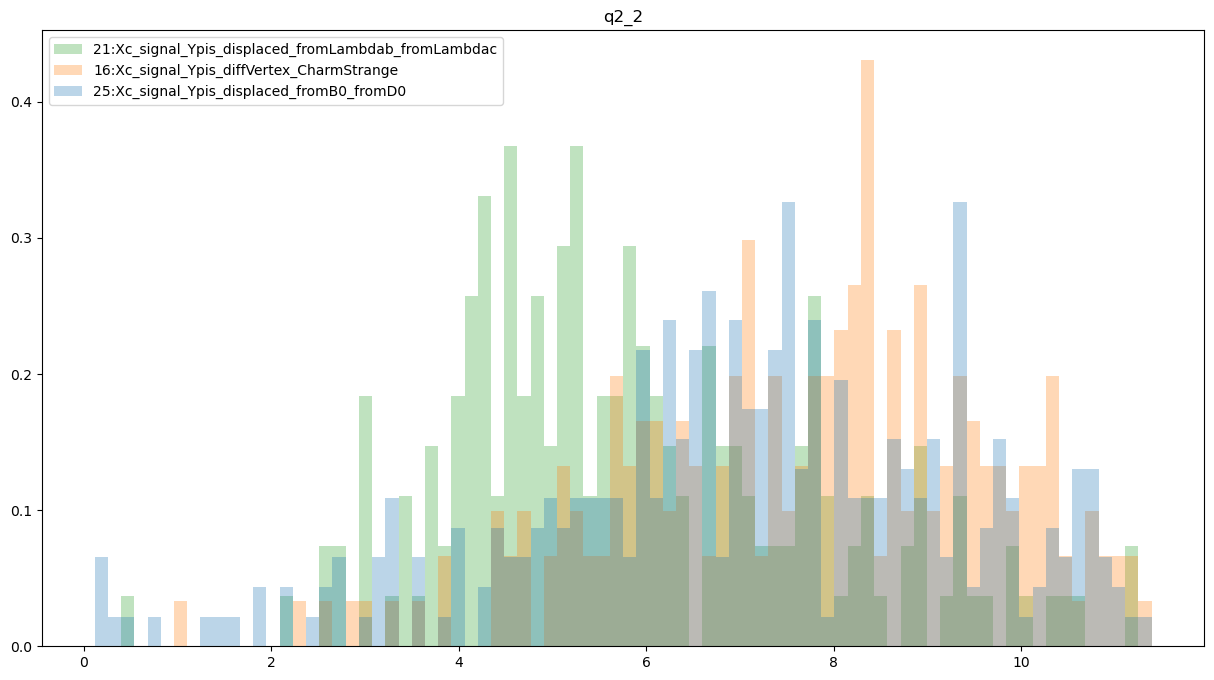

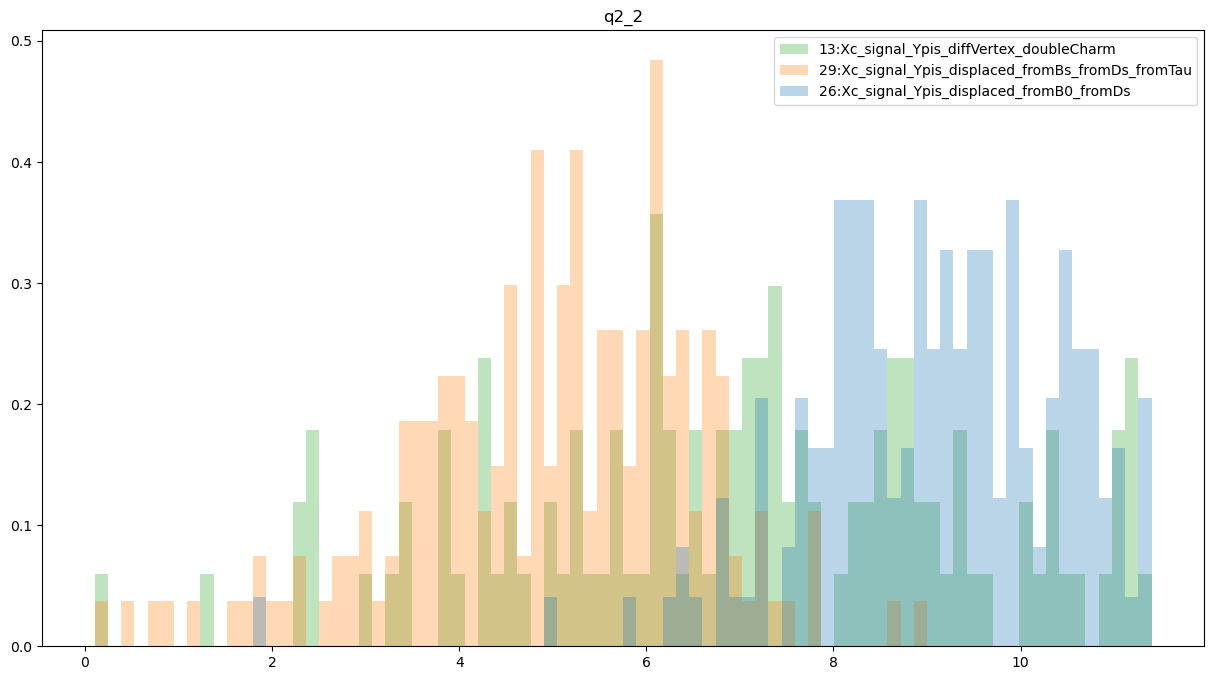

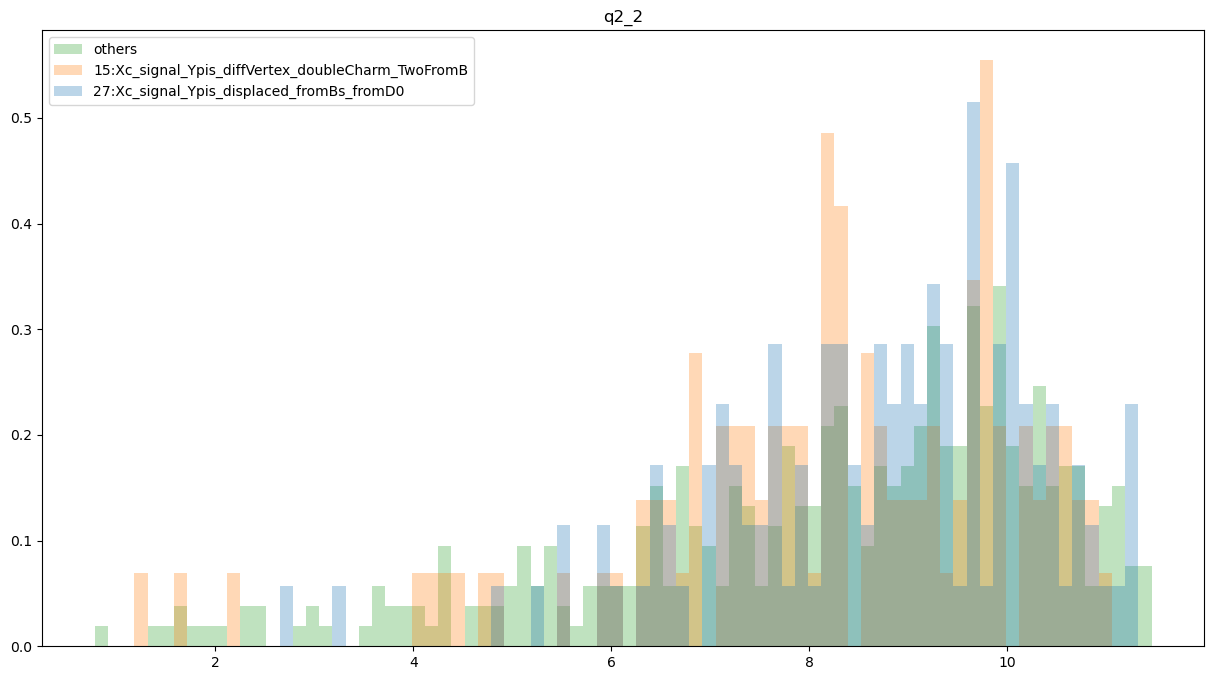

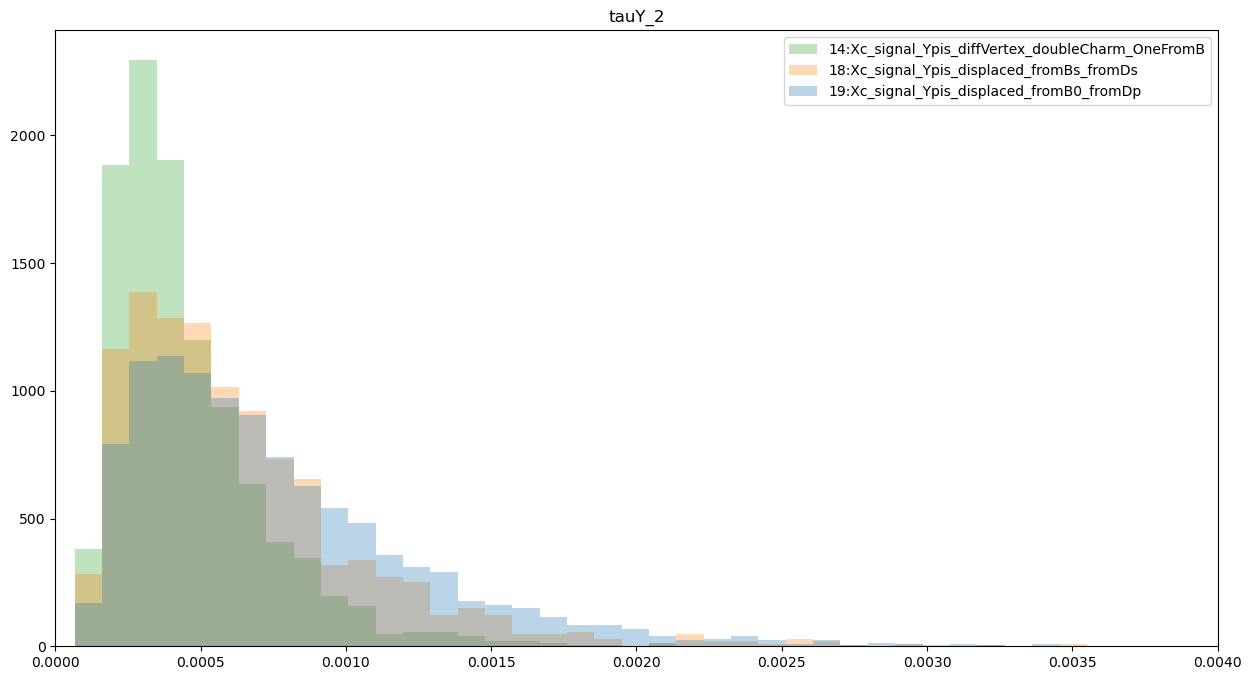

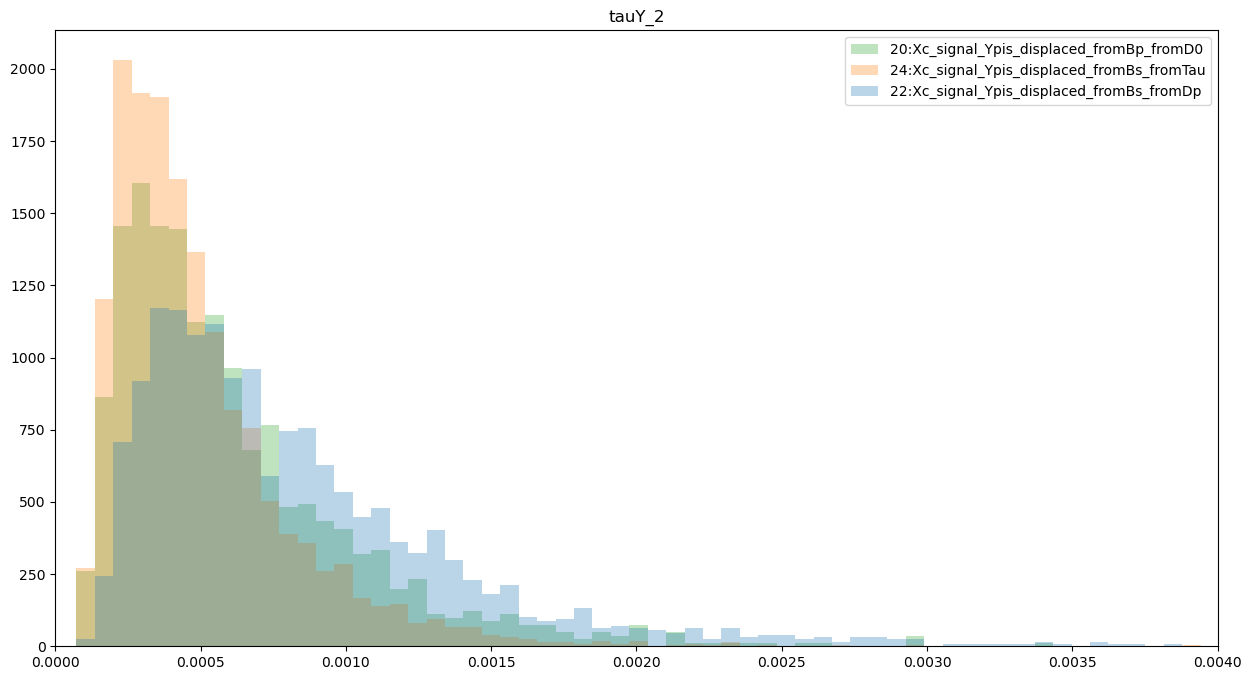

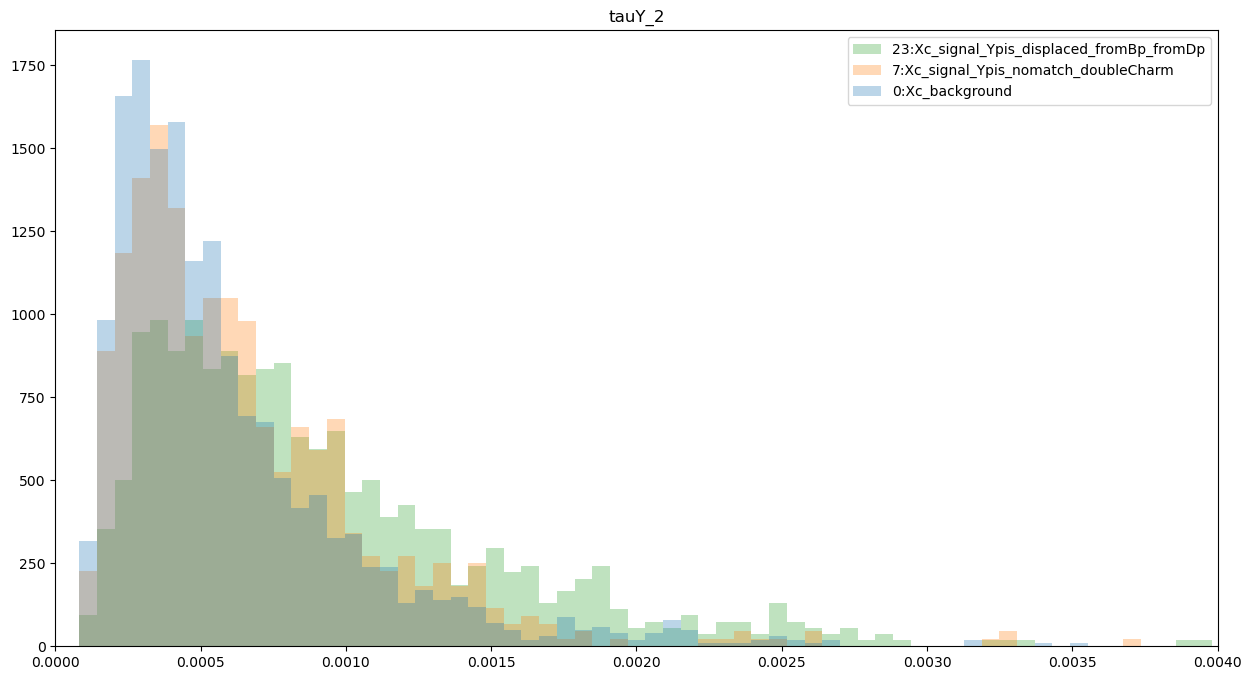

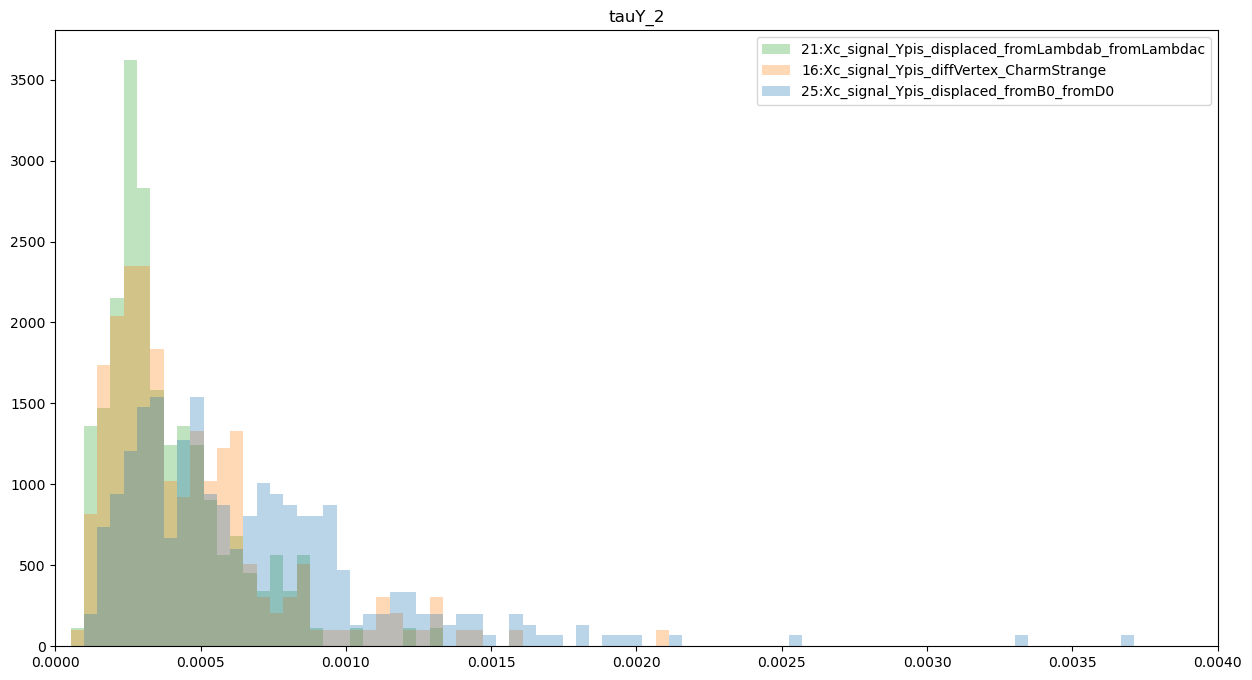

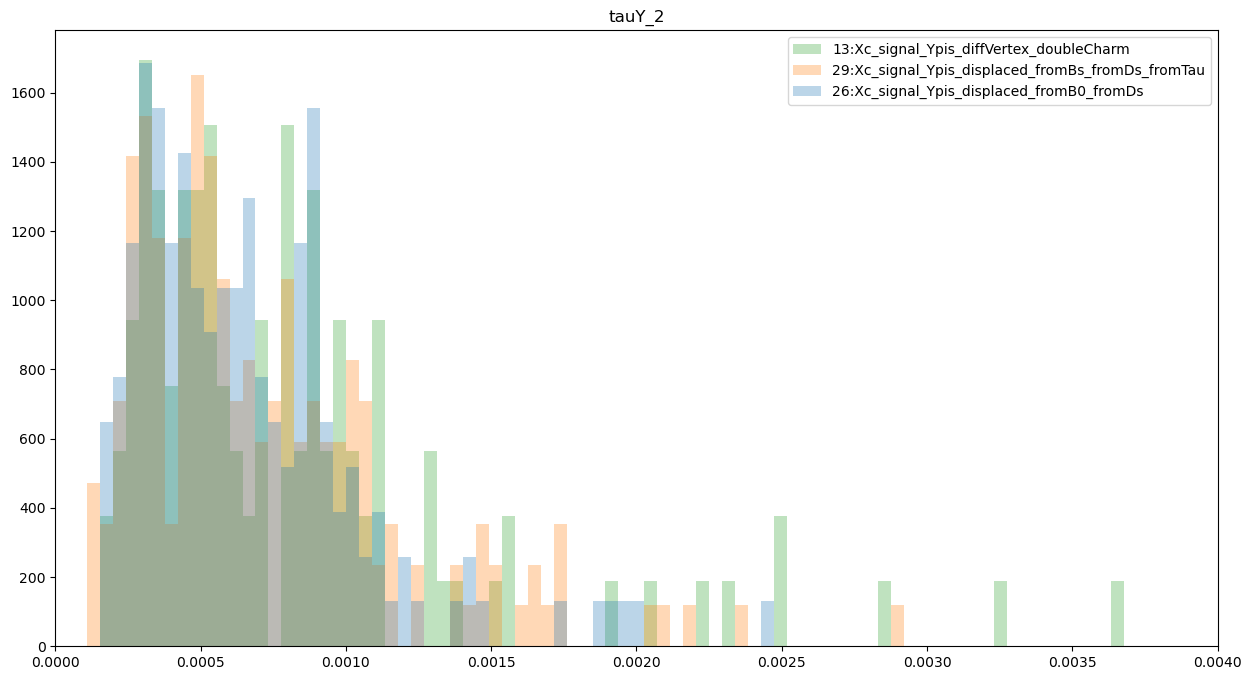

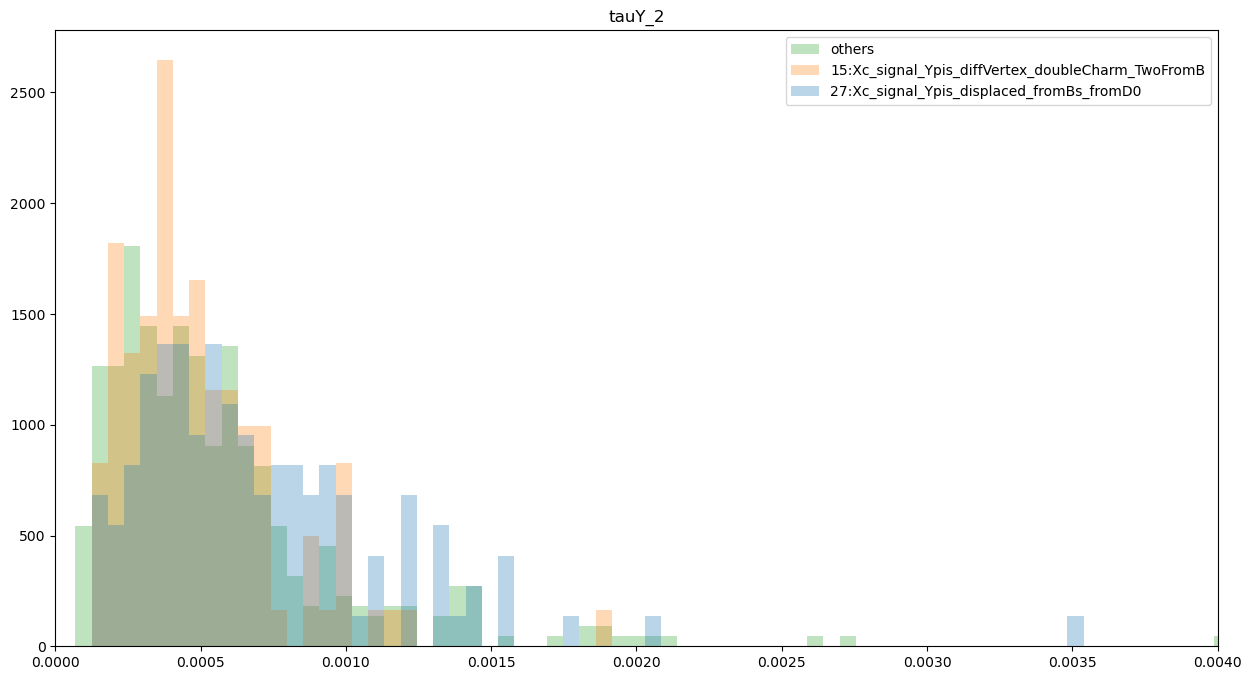

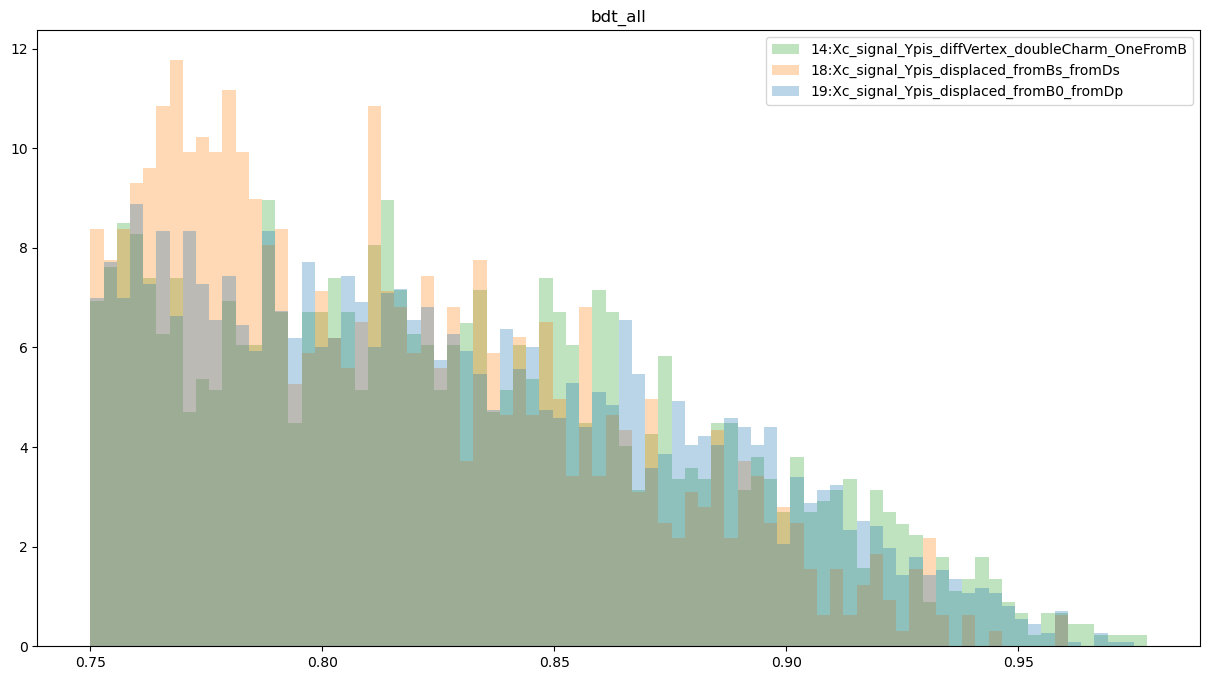

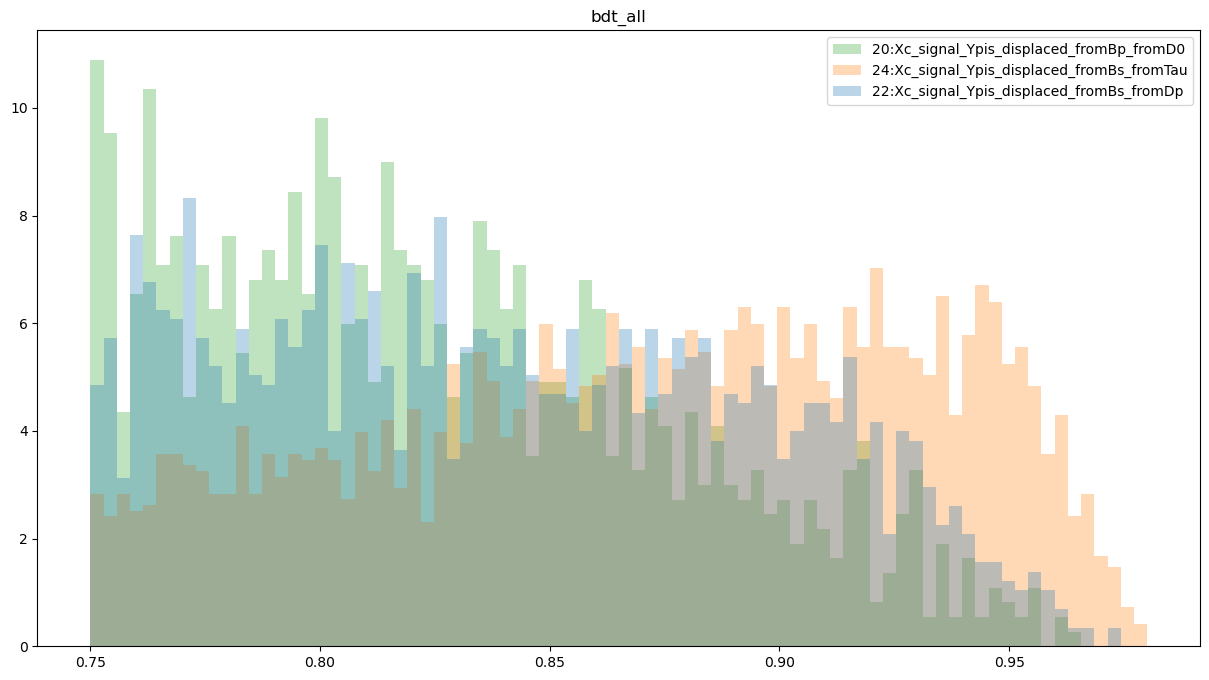

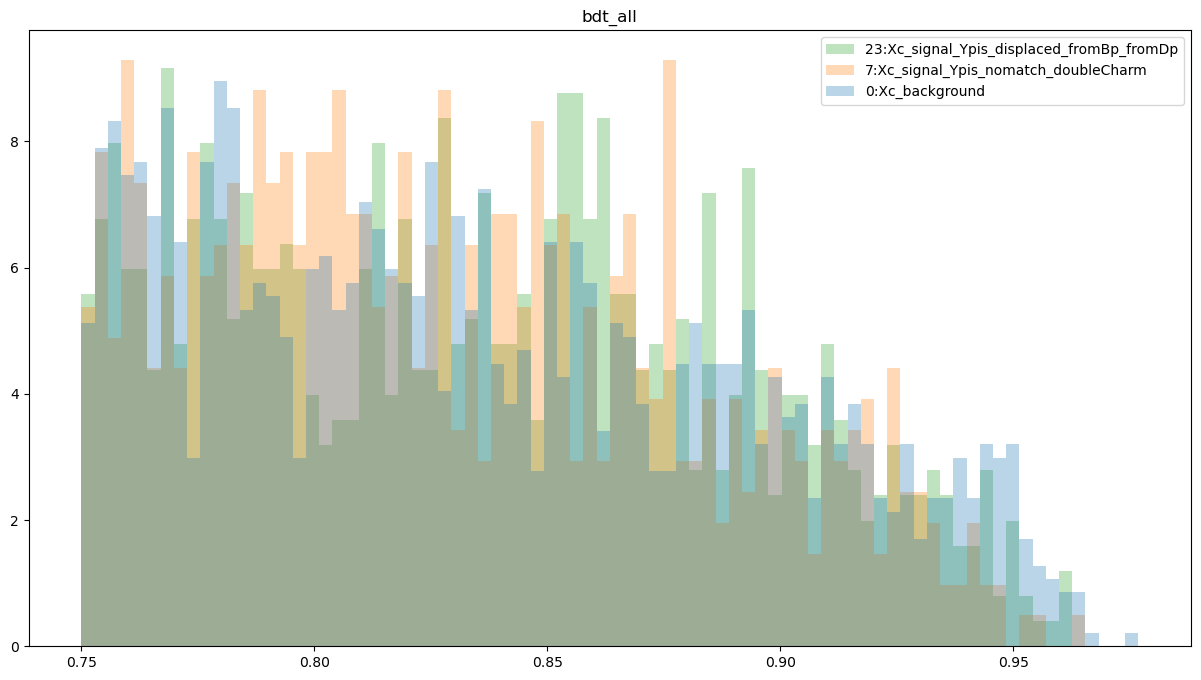

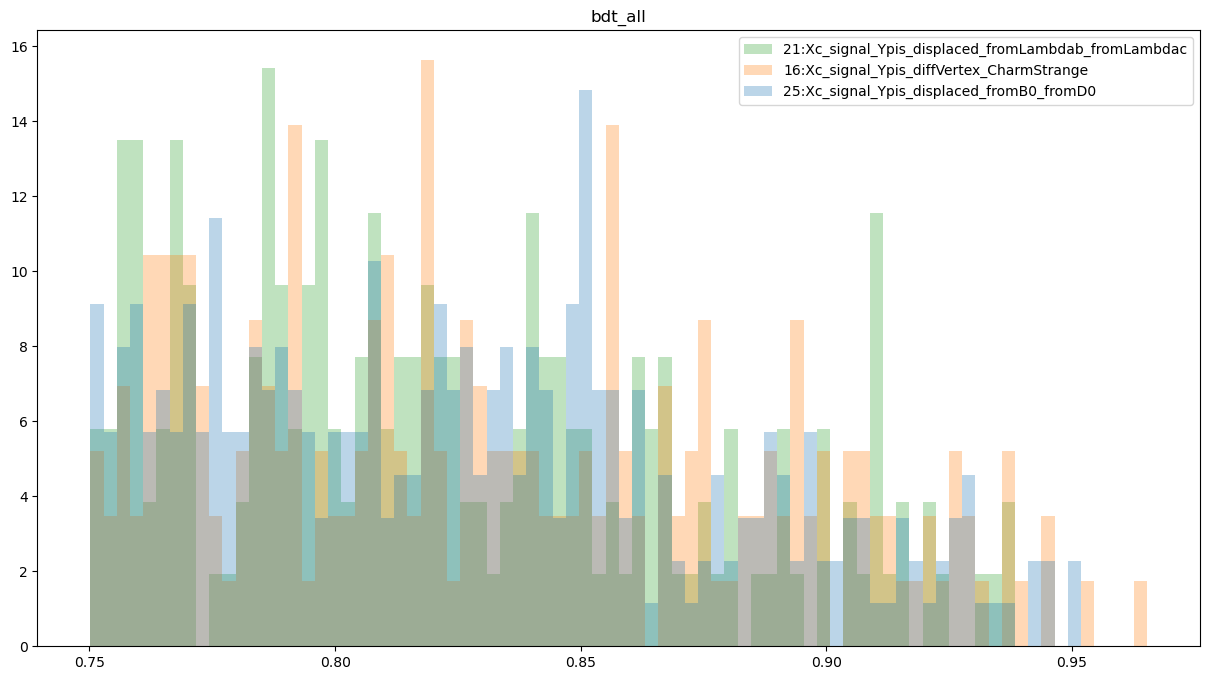

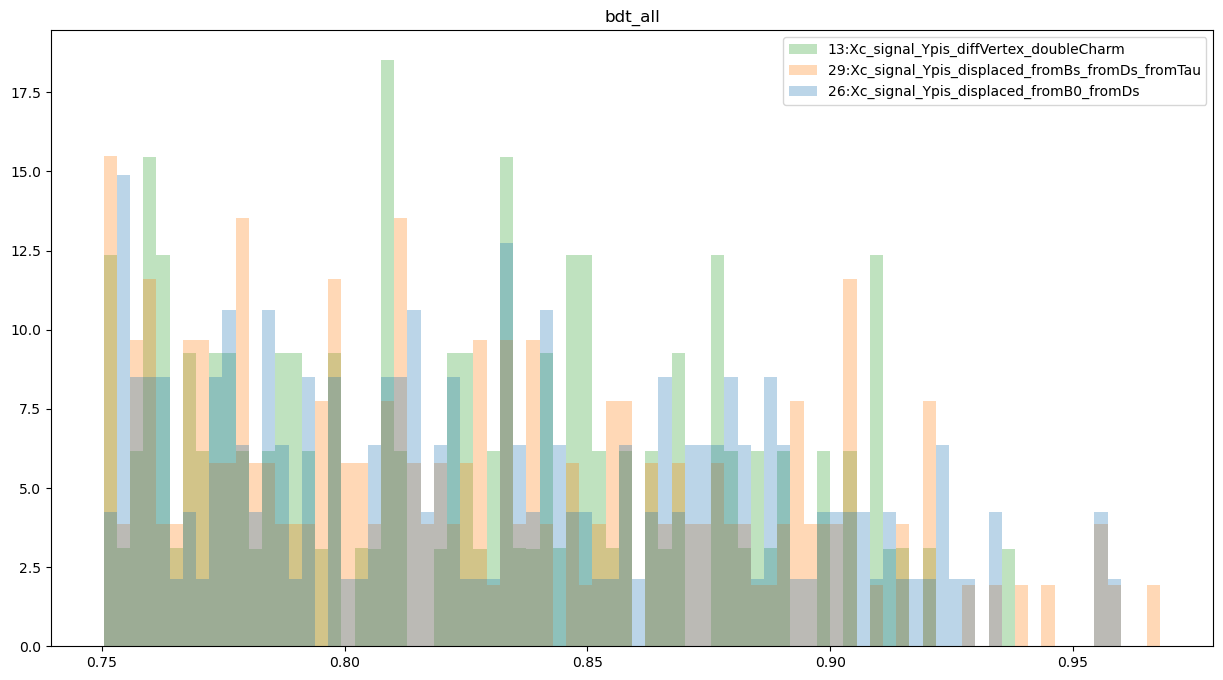

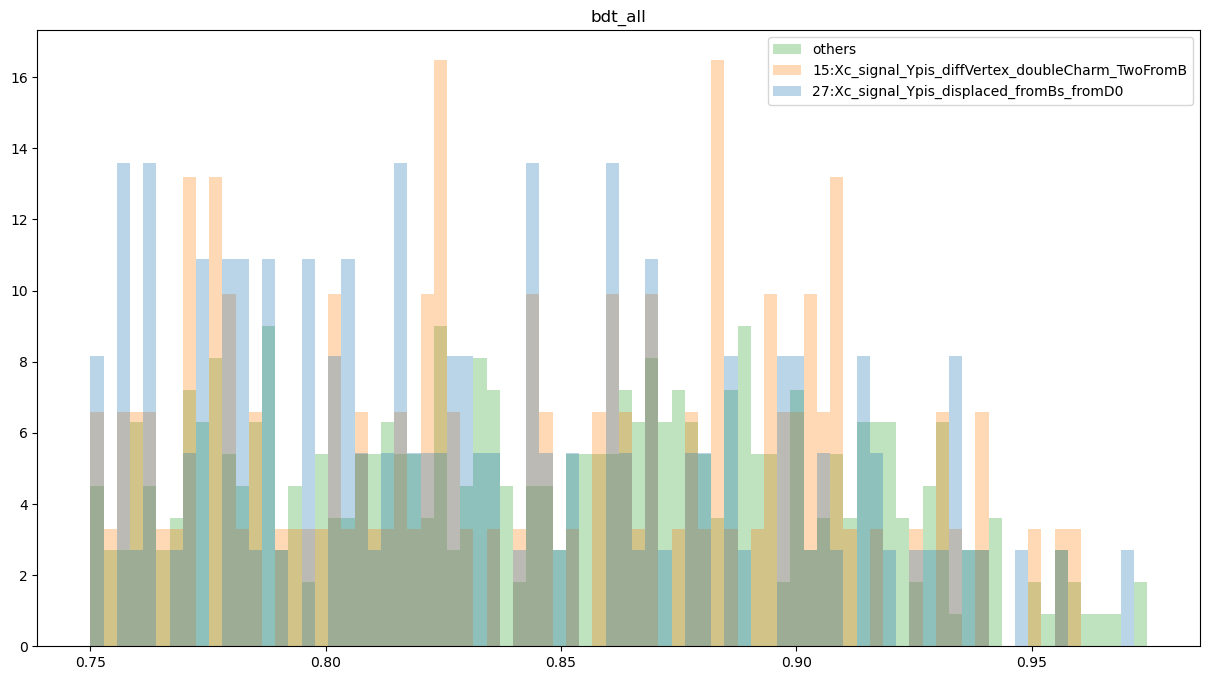

In [101]:

def plot_templates(datasets, datasets_names, myvar):
    htype = 'stepfilled'
    a = 0.30
    plt.hist([ d[myvar] for d in datasets ], bins=80, label=datasets_names, density=True, histtype=htype, alpha=a)
    if myvar == "tauY_2":
        plt.xlim([0, 0.004])
    plt.title(myvar)
    plt.legend()

#     ax2.hist([ d['tauY_2'] for d in datasets ] , bins=80, label=datasets_names, density=True, histtype=htype, alpha=a)
#     ax2.set_title("tauY_2")
#     ax2.set_xlim([0, 0.004])
#     ax2.legend()

#     ax3.hist([ d['bdt_all'] for d in datasets ] , bins=80, label=datasets_names, density=True, histtype=htype, alpha=a)
#     ax3.set_title("bdt_all")
#     ax3.legend()

n_in_plot = 3
for i in range(0, len(datasets), n_in_plot):
    plt.figure()
    plot_templates(datasets[i:i+n_in_plot], datasets_names[i:i+n_in_plot], 'q2_2')

for i in range(0, len(datasets), n_in_plot):
    plt.figure()
    plot_templates(datasets[i:i+n_in_plot], datasets_names[i:i+n_in_plot], 'tauY_2')

for i in range(0, len(datasets), n_in_plot):
    plt.figure() 
    plot_templates(datasets[i:i+n_in_plot], datasets_names[i:i+n_in_plot], 'bdt_all')

In [274]:
from scipy.stats import ks_2samp

# Perparing the list of categories to process
shown_number=17
shown_categs = list(c.head(shown_number)['category'])

datasets = { f"{c}":  dfcut1.query(f"category == {c}") for c in shown_categs }
datasets["others"] =  dfcut1.query(f"category not in {shown_categs}")
datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
datasets_names.append("others")
cols = np.array([ str(c) for c in shown_categs ] + [ "others" ])

# Preparing the matrix with the final results
stats= pd.DataFrame(np.zeros((shown_number +1, shown_number + 1)), columns=cols)
stats["name"] = cols.T
stats = stats.set_index("name", drop=True).copy()

stats_q2_2 = stats.copy()
stats_tauY_2 = stats.copy()
stats_bdt_all = stats.copy()


In [275]:
for i in range(len(cols)):
    for j in range(len(cols)):
        # Only deal with half the matrix
        if j > i:
            continue
        print(f"Comparing {cols[i]} with {cols[j]}")
        
        todo = { "q2_2": stats_q2_2,
                "tauY_2": stats_tauY_2,
                "bdt_all": stats_bdt_all,
    
             }
        for myvar, matrix in todo.items():
            res = ks_2samp(datasets[cols[i]][myvar], datasets[cols[j]][myvar])
            matrix[cols[i]][cols[j]] = res[1]
            matrix[cols[j]][cols[i]] = matrix[cols[i]][cols[j]] 
            
#         print(res)
#         print(res[1])
#         stats[cols[i]][cols[j]] = res[1]
#        stats[cols[j]][cols[i]] = stats[cols[i]][cols[j]] 

Comparing 19 with 19
Comparing 18 with 19
Comparing 18 with 18
Comparing 14 with 19
Comparing 14 with 18
Comparing 14 with 14
Comparing 22 with 19
Comparing 22 with 18
Comparing 22 with 14
Comparing 22 with 22
Comparing 24 with 19
Comparing 24 with 18
Comparing 24 with 14
Comparing 24 with 22
Comparing 24 with 24
Comparing 20 with 19
Comparing 20 with 18
Comparing 20 with 14
Comparing 20 with 22
Comparing 20 with 24
Comparing 20 with 20
Comparing 0 with 19
Comparing 0 with 18
Comparing 0 with 14
Comparing 0 with 22
Comparing 0 with 24
Comparing 0 with 20
Comparing 0 with 0
Comparing 7 with 19
Comparing 7 with 18
Comparing 7 with 14
Comparing 7 with 22
Comparing 7 with 24
Comparing 7 with 20
Comparing 7 with 0
Comparing 7 with 7
Comparing 23 with 19
Comparing 23 with 18
Comparing 23 with 14
Comparing 23 with 22
Comparing 23 with 24
Comparing 23 with 20
Comparing 23 with 0
Comparing 23 with 7
Comparing 23 with 23
Comparing 25 with 19
Comparing 25 with 18
Comparing 25 with 14
Comparing 25

,19,18,14,22,24,20,0,7,23,25,16,21,26,29,13,27,15,others
name,,,,,,,,,,,,,,,,,,
19,1.000000e+00,1.161871e-118,3.492766e-04,6.408022e-164,3.103512e-12,3.611140e-07,6.641349e-39,5.948389e-02,2.429315e-46,1.813043e-01,8.489367e-05,3.897046e-13,1.400465e-34,5.341772e-37,8.072572e-01,1.074198e-15,2.599078e-08,4.306590e-23
18,1.161871e-118,1.000000e+00,9.972051e-106,9.535467e-322,2.426842e-166,1.205889e-52,4.896190e-199,1.887063e-68,2.459173e-200,1.009038e-41,2.186823e-49,1.422736e-03,3.490078e-109,1.769041e-01,7.277179e-18,5.033763e-66,7.165117e-44,2.587737e-107
14,3.492766e-04,9.972051e-106,1.000000e+00,6.433754e-132,4.746245e-10,6.463906e-10,9.537510e-38,7.283807e-05,7.671571e-44,1.636519e-01,1.575410e-05,1.655419e-17,5.962880e-37,6.127920e-39,3.537601e-01,3.941707e-18,1.484108e-08,1.584192e-27
22,6.408022e-164,9.535467e-322,6.433754e-132,1.000000e+00,2.382666e-106,4.068233e-145,2.945648e-27,3.001000e-51,2.550711e-08,3.786095e-40,5.896745e-13,1.966808e-60,4.740155e-02,2.333606e-116,2.185922e-16,9.727761e-01,5.094702e-03,5.212570e-05
24,3.103512e-12,2.426842e-166,4.746245e-10,2.382666e-106,1.000000e+00,6.839699e-21,2.348128e-18,3.266634e-02,4.204908e-25,1.188735e-02,1.388995e-01,2.342088e-21,2.474736e-25,1.026898e-50,2.181371e-01,4.095933e-11,5.766624e-05,2.340402e-15
20,3.611140e-07,1.205889e-52,6.463906e-10,4.068233e-145,6.839699e-21,1.000000e+00,4.433319e-49,1.305064e-07,6.805738e-56,8.335640e-04,1.878709e-09,1.679791e-07,3.542072e-43,1.047129e-23,8.737654e-02,3.443400e-22,5.846934e-13,1.464363e-33
0,6.641349e-39,4.896190e-199,9.537510e-38,2.945648e-27,2.348128e-18,4.433319e-49,1.000000e+00,6.181153e-12,8.845100e-06,3.788421e-12,1.584531e-02,2.730972e-30,6.128263e-12,5.039769e-68,2.792193e-05,4.602133e-04,1.189129e-01,4.287417e-03
7,5.948389e-02,1.887063e-68,7.283807e-05,3.001000e-51,3.266634e-02,1.305064e-07,6.181153e-12,1.000000e+00,2.441656e-21,1.914821e-01,4.433183e-03,3.505205e-13,1.642632e-23,1.489162e-34,6.068119e-01,1.022205e-11,3.775832e-06,7.204359e-12
23,2.429315e-46,2.459173e-200,7.671571e-44,2.550711e-08,4.204908e-25,6.805738e-56,8.845100e-06,2.441656e-21,1.000000e+00,3.863802e-17,2.920541e-05,2.209927e-41,1.184318e-06,1.099774e-83,1.309645e-08,7.931907e-02,6.265033e-01,9.693608e-02


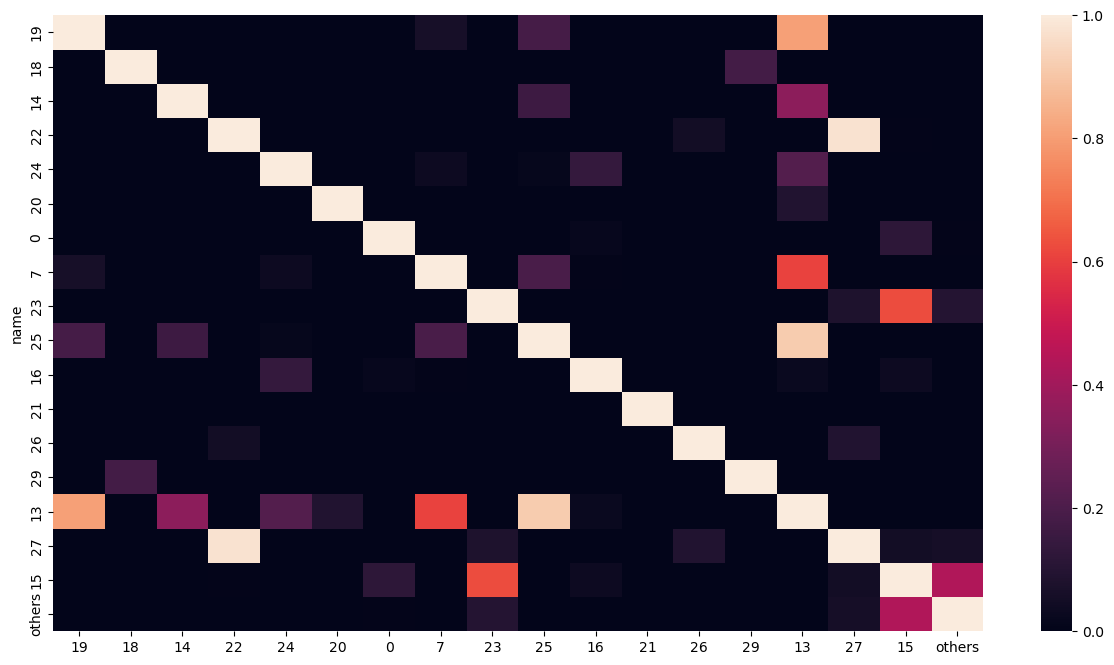

In [276]:
import seaborn as sn
sn.heatmap(stats_q2_2)
stats_q2_2

,19,18,14,22,24,20,0,7,23,25,16,21,26,29,13,27,15,others
name,,,,,,,,,,,,,,,,,,
19,1.000000e+00,2.343446e-11,8.977537e-107,1.748917e-03,1.272571e-125,5.482508e-20,1.188882e-36,8.522871e-06,1.594343e-08,1.075654e-02,1.373255e-19,1.717632e-27,1.077931e-02,3.586095e-01,7.268643e-01,3.598016e-01,3.159768e-08,3.100250e-15
18,2.343446e-11,1.000000e+00,7.605198e-29,7.528281e-18,1.559366e-23,7.959910e-02,9.142299e-05,1.846438e-01,1.579526e-22,5.694575e-02,1.296304e-08,1.093559e-14,2.510930e-01,4.419193e-02,2.134871e-03,1.543494e-01,1.971036e-03,3.521133e-03
14,8.977537e-107,7.605198e-29,1.000000e+00,5.924171e-105,1.468956e-03,1.012524e-21,5.572328e-16,3.081303e-25,6.823933e-93,6.314454e-19,3.977477e-01,4.732334e-04,4.145522e-12,1.642295e-15,6.289267e-12,5.083363e-11,5.844899e-02,6.171536e-06
22,1.748917e-03,7.528281e-18,5.924171e-105,1.000000e+00,3.216146e-115,7.524662e-27,7.295785e-43,5.183487e-10,3.223542e-03,1.402153e-04,1.293914e-23,2.120712e-32,5.658762e-04,4.563891e-02,5.854744e-01,6.024335e-02,1.807583e-10,4.803121e-21
24,1.272571e-125,1.559366e-23,1.468956e-03,3.216146e-115,1.000000e+00,1.386152e-15,4.406601e-10,4.016784e-20,2.725660e-92,8.556655e-15,5.862934e-02,1.861380e-06,2.318217e-09,5.552480e-12,5.818678e-10,1.546583e-08,3.433848e-01,2.047598e-03
20,5.482508e-20,7.959910e-02,1.012524e-21,7.524662e-27,1.386152e-15,1.000000e+00,1.249801e-01,3.594257e-02,3.569201e-30,2.998682e-03,2.897427e-06,7.174963e-12,1.658567e-02,1.698382e-03,4.279869e-04,1.516849e-02,2.218986e-02,2.619413e-02
0,1.188882e-36,9.142299e-05,5.572328e-16,7.295785e-43,4.406601e-10,1.249801e-01,1.000000e+00,3.665426e-05,1.993249e-43,3.253582e-05,5.878442e-05,3.343016e-10,7.480206e-04,3.250461e-05,4.600132e-05,9.246245e-04,9.278602e-02,1.876750e-01
7,8.522871e-06,1.846438e-01,3.081303e-25,5.183487e-10,4.016784e-20,3.594257e-02,3.665426e-05,1.000000e+00,2.630444e-15,2.804965e-01,2.357327e-08,4.876866e-14,4.476152e-01,6.817353e-02,1.791855e-02,1.791720e-01,8.486344e-04,2.671073e-04
23,1.594343e-08,1.579526e-22,6.823933e-93,3.223542e-03,2.725660e-92,3.569201e-30,1.993249e-43,2.630444e-15,1.000000e+00,3.674519e-08,4.586647e-28,3.050273e-36,1.171088e-06,7.493925e-04,4.172225e-02,1.434067e-03,1.376801e-13,8.468826e-25


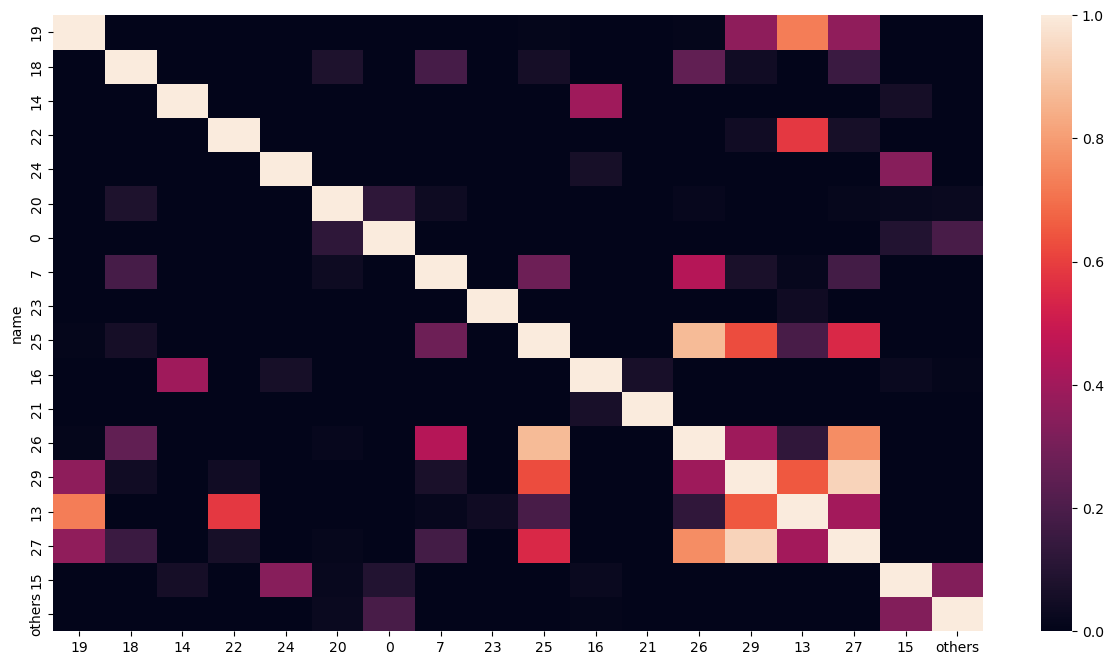

In [277]:

sn.heatmap(stats_tauY_2)
stats_tauY_2

,19,18,14,22,24,20,0,7,23,25,16,21,26,29,13,27,15,others
name,,,,,,,,,,,,,,,,,,
19,1.000000e+00,1.493738e-08,1.903852e-01,3.256090e-13,1.023278e-155,1.335430e-01,2.542059e-06,2.605403e-01,1.322508e-06,6.116859e-01,4.868832e-01,4.172568e-01,3.064056e-01,9.633908e-01,9.839630e-01,2.144480e-01,0.007526,2.313101e-11
18,1.493738e-08,1.000000e+00,2.838512e-09,1.664173e-26,7.179298e-127,8.449300e-06,3.074662e-16,1.005276e-06,4.257098e-17,3.269714e-04,3.366762e-04,2.745253e-02,4.492093e-04,2.538260e-02,4.284472e-02,7.084737e-04,0.000003,1.446047e-21
14,1.903852e-01,2.838512e-09,1.000000e+00,5.105481e-09,1.714861e-91,2.225224e-02,6.142593e-04,8.535788e-01,7.570727e-04,5.499297e-01,7.399043e-01,1.952557e-01,3.858760e-01,6.870407e-01,7.736386e-01,3.574762e-01,0.015131,3.544783e-09
22,3.256090e-13,1.664173e-26,5.105481e-09,1.000000e+00,3.316199e-50,5.100077e-13,1.016109e-02,6.065228e-05,7.400255e-02,2.246175e-05,1.972707e-01,1.215119e-04,3.886065e-01,1.326329e-02,3.104973e-02,7.280195e-01,0.806131,1.557957e-02
24,1.023278e-155,7.179298e-127,1.714861e-91,3.316199e-50,1.000000e+00,2.413296e-97,1.360336e-63,3.513262e-50,8.461301e-41,6.783802e-33,4.693668e-15,2.083648e-23,1.924822e-11,3.345217e-17,1.629246e-12,2.430093e-08,0.000098,1.176819e-09
20,1.335430e-01,8.449300e-06,2.225224e-02,5.100077e-13,2.413296e-97,1.000000e+00,1.460804e-06,8.845354e-02,7.844630e-08,4.491341e-01,1.551622e-01,9.526740e-01,7.968787e-02,8.108550e-01,8.890114e-01,7.226616e-02,0.001452,2.640157e-12
0,2.542059e-06,3.074662e-16,6.142593e-04,1.016109e-02,1.360336e-63,1.460804e-06,1.000000e+00,2.584856e-03,1.293998e-01,5.923671e-03,8.446691e-01,4.197909e-03,6.308508e-01,3.126293e-01,1.301546e-01,9.880500e-01,0.227070,9.985859e-05
7,2.605403e-01,1.005276e-06,8.535788e-01,6.065228e-05,3.513262e-50,8.845354e-02,2.584856e-03,1.000000e+00,4.476053e-03,4.876671e-01,7.648044e-01,2.207142e-01,6.894027e-01,4.682778e-01,7.435860e-01,4.847059e-01,0.023945,2.002628e-07
23,1.322508e-06,4.257098e-17,7.570727e-04,7.400255e-02,8.461301e-41,7.844630e-08,1.293998e-01,4.476053e-03,1.000000e+00,1.375224e-03,3.757460e-01,6.098660e-04,6.144146e-01,3.664368e-02,5.678713e-02,8.630794e-01,0.337415,7.970841e-04


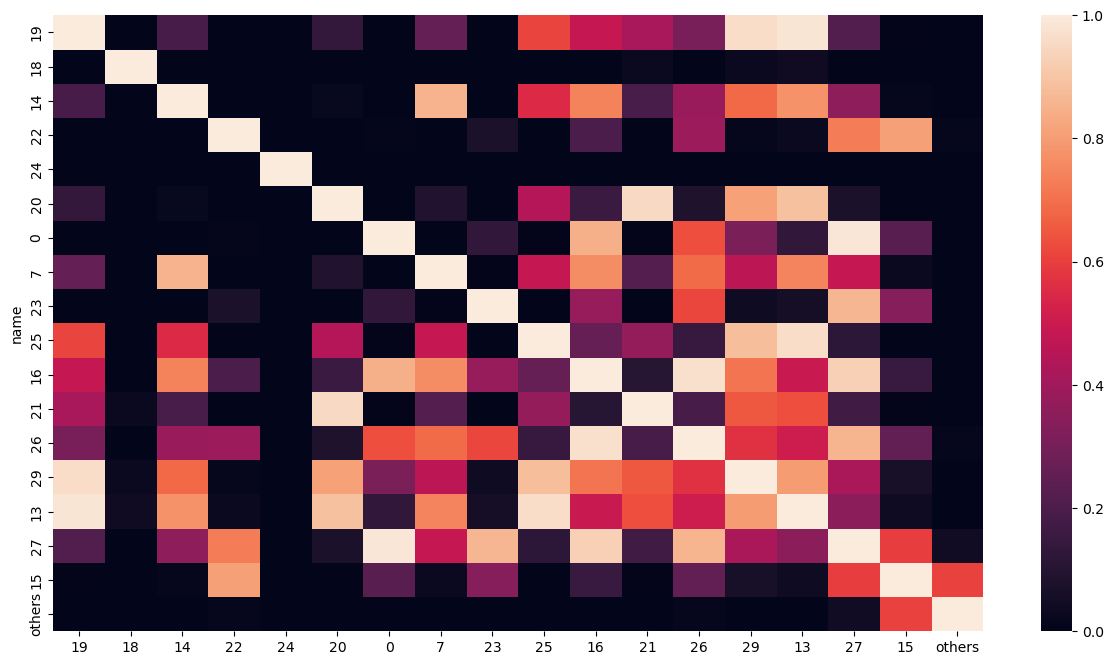

In [278]:

sn.heatmap(stats_bdt_all)
stats_bdt_all

## Checking CUT2 i.e. BDT_all > 0.35

In [279]:
dfcut2 = df.query("bdt_all > 0.35")

In [280]:
c = mygroupby(dfcut2, 'category')
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c

,category,count,Percentage,cumulative %,name
0,19,21750,25.194607,25.194607,Xc_signal_Ypis_displaced_fromB0_fromDp
1,18,10558,12.230099,37.424706,Xc_signal_Ypis_displaced_fromBs_fromDs
2,14,9044,10.476323,47.901029,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB
3,20,8030,9.301733,57.202762,Xc_signal_Ypis_displaced_fromBp_fromD0
4,0,7367,8.533732,65.736493,Xc_background
5,22,7092,8.215179,73.951673,Xc_signal_Ypis_displaced_fromBs_fromDp
6,24,5483,6.351358,80.303030,Xc_signal_Ypis_displaced_fromBs_fromTau
7,7,4210,4.876749,85.179779,Xc_signal_Ypis_nomatch_doubleCharm
8,23,3531,4.090214,89.269994,Xc_signal_Ypis_displaced_fromBp_fromDp
9,25,1862,2.156890,91.426884,Xc_signal_Ypis_displaced_fromB0_fromD0


In [323]:
from scipy.stats import ks_2samp

def similar_categories(df, shown_number=17):
    """ Finding which categories have similar histograms for q2_2, tauY_2, bdt_all """
    
    # Grouping the samples per category
    c = mygroupby(df, 'category')
    c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
    
    # Preparing the list of categories to process
    #shown_number=17
    shown_categs = list(c.head(shown_number)['category'])

    # Building a list of detasets filtered 
    datasets = { f"{c}":  df.query(f"category == {c}") for c in shown_categs }
    datasets["others"] =  df.query(f"category not in {shown_categs}")
    datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
    datasets_names.append("others")
    
    # List of column names
    cols = np.array([ str(c) for c in shown_categs ] + [ "others" ])

    # Preparing the matrix with the final results
    stats= pd.DataFrame(np.zeros((shown_number +1, shown_number + 1)), columns=cols)
    stats["name"] = cols.T
    stats = stats.set_index("name", drop=True).copy()

    stats_q2_2 = stats.copy()
    stats_tauY_2 = stats.copy()
    stats_bdt_all = stats.copy()
    
    for i in range(len(cols)):
        for j in range(len(cols)):
            # Only deal with half the matrix
            if j > i:
                continue
            
            todo = { "q2_2": stats_q2_2,
                     "tauY_2": stats_tauY_2,
                     "bdt_all": stats_bdt_all,
                   }
            for myvar, matrix in todo.items():
                res = ks_2samp(datasets[cols[i]][myvar], datasets[cols[j]][myvar], alternative='two-sided', method='exact')
                matrix[cols[i]][cols[j]] = res[1]
                matrix[cols[j]][cols[i]] = matrix[cols[i]][cols[j]] 
    return stats_q2_2, stats_tauY_2, stats_bdt_all

sq2_2, stauY_2, sbdt_all = similar_categories(dfcut2, 17)

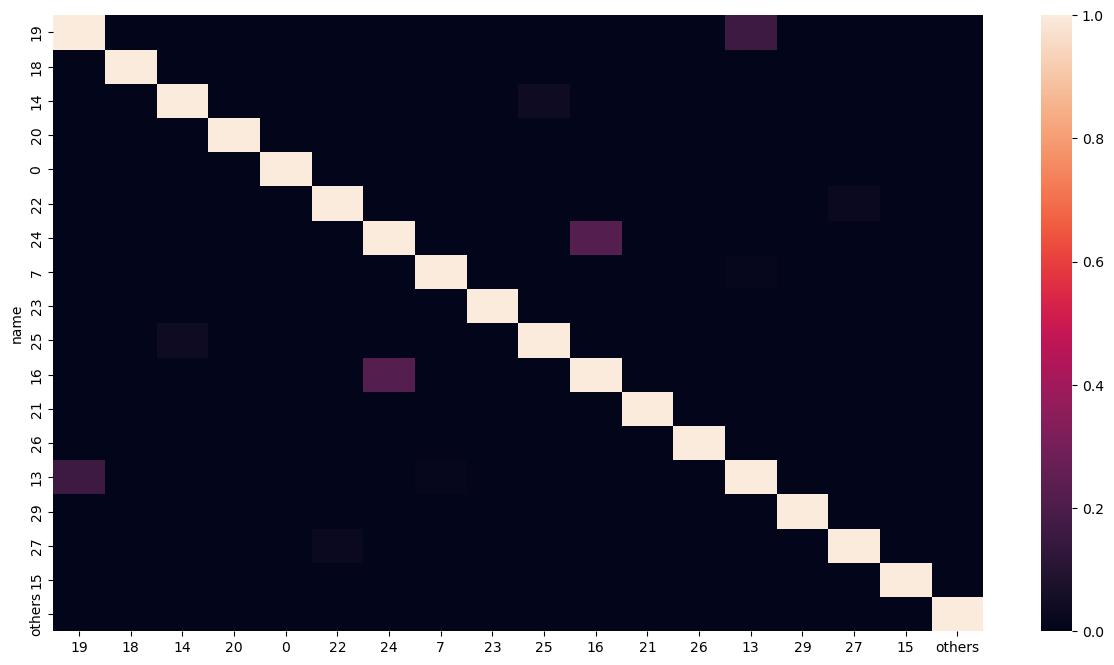

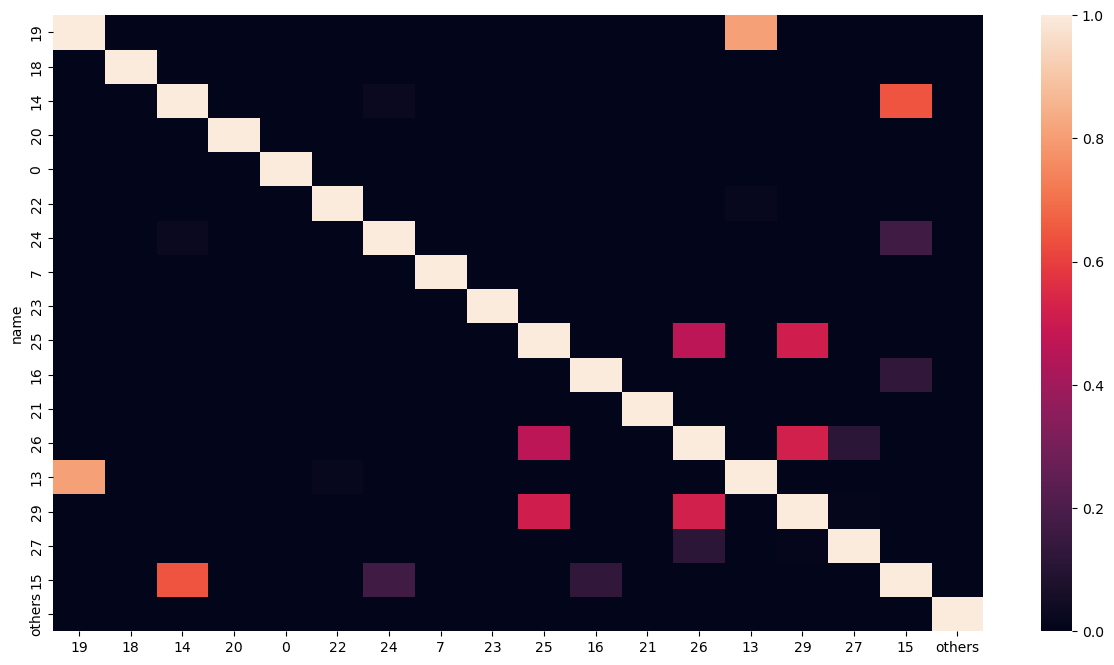

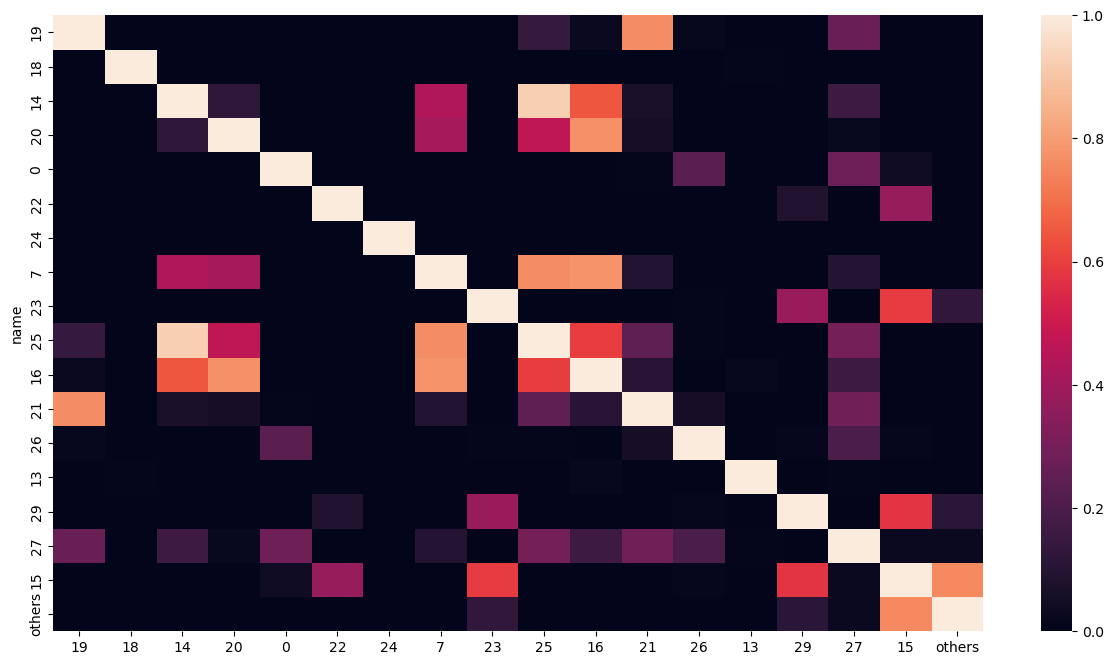

In [324]:
plt.figure()
sn.heatmap(sq2_2)
plt.figure()
sn.heatmap(stauY_2)
plt.figure()
sn.heatmap(sbdt_all);

In [325]:
sq2_2.round(2)

,19,18,14,20,0,22,24,7,23,25,16,21,26,13,29,27,15,others
name,,,,,,,,,,,,,,,,,,
19,1.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.16,0.0,0.00,0.0,0.0
18,0.00,1.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0
14,0.00,0.0,1.00,0.0,0.0,0.00,0.00,0.00,0.0,0.04,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0
20,0.00,0.0,0.00,1.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0
0,0.00,0.0,0.00,0.0,1.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0
22,0.00,0.0,0.00,0.0,0.0,1.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.02,0.0,0.0
24,0.00,0.0,0.00,0.0,0.0,0.00,1.00,0.00,0.0,0.00,0.22,0.0,0.0,0.00,0.0,0.00,0.0,0.0
7,0.00,0.0,0.00,0.0,0.0,0.00,0.00,1.00,0.0,0.00,0.00,0.0,0.0,0.01,0.0,0.00,0.0,0.0
23,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,1.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0


In [372]:
def find_clusters(m, threshold):
    allsets = set()
    for i in m.index:
        s = frozenset(m[m[i] > threshold][i].index)
        if s:
            allsets.add(s)
    return allsets

# Iterative
def merge_clusters(clusters):
    final = []
    tomerge = list(clusters)
    while True:
        h = tomerge[0]
        t = tomerge[1:]
        if not t:
            final.append(h)
            break
        tmp = []
        merged = False
        for c in t:
            if h & c:
                tmp.append( h | c)
                merged = True
            else:
                tmp.append(c)
        if not merged:
            final.append(h)
        tomerge = tmp
    return final

def merge_clusters_rec(unmerged, merged):
    """ Merge sets with non null intersection """
    h = unmerged[0]
    t = unmerged[1:]
    
    # End of recursion if ony one element in the list,nothing to merge to....
    if not t:
        merged.append(h)
        return t, merged
    
    # Iterate over the list of elements, comparing the first one h,
    # with all the others. If h has no intersection we add it to the
    # list of processed elements (merged), otherwise we merge it to the
    # element in common and we iterate the function again on the 
    # new list containing this new element plus the others
    tmp = []
    was_merged = False
    for c in t:
        if h & c:
            tmp.append( h | c)
            was_merged = True
        else:
            tmp.append(c)
    if not was_merged:
        merged.append(h)

    return merge_clusters_rec(tmp, merged)


def find_and_merge_clusters(m, threshold=0.5):
    clusters = find_clusters(m, threshold)
    unmerged, merged = merge_clusters_rec(list(clusters), [])
    return [ list(s) for s in merged ]


In [374]:
pprint(find_clusters(sq2_2, 0.1))
pprint(find_and_merge_clusters(sq2_2, 0.1))

{frozenset({'13', '19'}),
 frozenset({'22'}),
 frozenset({'15'}),
 frozenset({'24', '16'}),
 frozenset({'20'}),
 frozenset({'18'}),
 frozenset({'29'}),
 frozenset({'23'}),
 frozenset({'25'}),
 frozenset({'26'}),
 frozenset({'0'}),
 frozenset({'21'}),
 frozenset({'14'}),
 frozenset({'7'}),
 frozenset({'others'}),
 frozenset({'27'})}
[['13', '19'],
 ['22'],
 ['15'],
 ['24', '16'],
 ['20'],
 ['18'],
 ['29'],
 ['23'],
 ['25'],
 ['26'],
 ['0'],
 ['21'],
 ['14'],
 ['7'],
 ['others'],
 ['27']]


In [355]:
pprint(find_and_merge_clusters(stauY_2, 0.5))

[['15',
  '7',
  'others',
  '14',
  '0',
  '21',
  '29',
  '20',
  '18',
  '26',
  '13',
  '27',
  '24',
  '23',
  '22',
  '19',
  '16',
  '25']]


In [340]:
categories

{'0': 'Xc_background',
 '1': 'Xc_signal_Ypis_diffAncestorYXc',
 '2': 'Xc_signal_Ypis_B_vertex_fromBs',
 '3': 'Xc_signal_Ypis_B_vertex_fromOtherB',
 '4': 'Xc_signal_Ypis_B_vertex_fromHc',
 '5': 'Xc_signal_Ypis_B_vertex_fromNone',
 '6': 'Xc_signal_Ypis_nomatch_Prompt',
 '7': 'Xc_signal_Ypis_nomatch_doubleCharm',
 '8': 'Xc_signal_Ypis_nomatch_charmStrange',
 '9': 'Xc_signal_Ypis_nomatch_Other',
 '10': 'Xc_signal_Ypis_diffVertex_signal',
 '11': 'Xc_signal_Ypis_diffVertex_tauFromB',
 '12': 'Xc_signal_Ypis_diffVertex_normlike',
 '13': 'Xc_signal_Ypis_diffVertex_doubleCharm',
 '14': 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB',
 '15': 'Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB',
 '16': 'Xc_signal_Ypis_diffVertex_CharmStrange',
 '17': 'Xc_signal_Ypis_diffVertex_SomeFromPV',
 '18': 'Xc_signal_Ypis_displaced_fromBs_fromDs',
 '19': 'Xc_signal_Ypis_displaced_fromB0_fromDp',
 '20': 'Xc_signal_Ypis_displaced_fromBp_fromD0',
 '21': 'Xc_signal_Ypis_displaced_fromLambdab_fromLambdac',
 '22': '

In [341]:
pprint(find_and_merge_clusters(sbdt_all, 0.01))

[['15',
  '7',
  'others',
  '14',
  '0',
  '21',
  '29',
  '20',
  '18',
  '26',
  '13',
  '27',
  '24',
  '23',
  '22',
  '19',
  '16',
  '25']]


## Exploring the histograms

In [395]:
shown_number=17

shown_categs = list(c.head(shown_number)['category'])
datasets = { f"{c}":  dfcut1.query(f"category == {c}") for c in shown_categs }
datasets["others"] =  dfcut1.query(f"category not in {shown_categs}")
datasets_names = { f"{c}": f"{c}:" + categories[f"{c}"] for c in shown_categs}
datasets_names["others"] = "others"

def plot_templates(datasets, datasets_names, myvar):
    htype = 'stepfilled'
    a = 0.30
    plt.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    if myvar == "tauY_2":
        plt.xlim([0, 0.004])
    plt.title(myvar)
    plt.legend()

def plot_templates_categs(mycategs, myvar):
    plot_templates([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar)


In [396]:
pprint(find_and_merge_clusters(stauY_2, 0.5))

[['13', '19'],
 ['22'],
 ['24'],
 ['20'],
 ['18'],
 ['23'],
 ['0'],
 ['16'],
 ['21'],
 ['7'],
 ['26', '29', '25'],
 ['27'],
 ['others'],
 ['14', '15']]


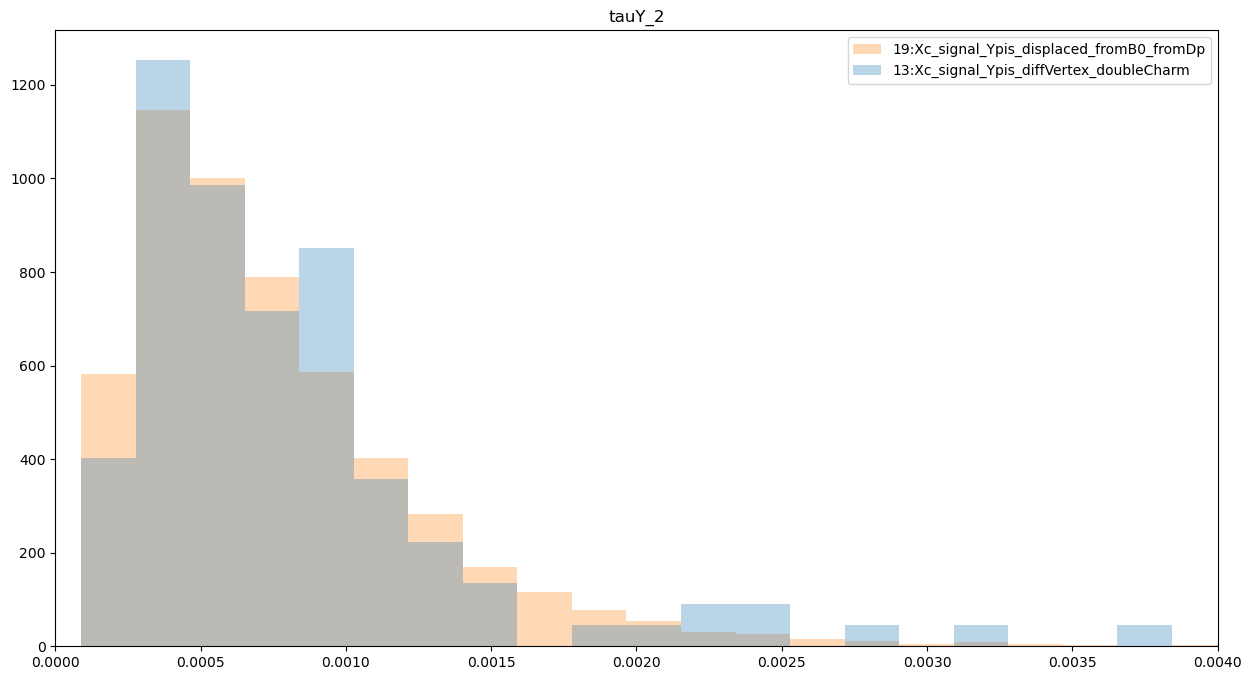

In [397]:
plot_templates_categs( ['13', '19'], "tauY_2")

## Comparing the histograms for CUT1 (tight)

(array([658., 682., 680., 695., 630., 660., 659., 580., 616., 597., 649.,
        622., 613., 607., 590., 564., 551., 574., 556., 544., 529., 452.,
        482., 451., 488., 420., 398., 383., 368., 344., 297., 278., 239.,
        252., 205., 162., 125.,  70.,  38.,  16.]),
 array([0.75001198, 0.75576216, 0.76151228, 0.76726246, 0.77301264,
        0.77876276, 0.78451294, 0.79026312, 0.79601324, 0.80176342,
        0.80751359, 0.81326371, 0.81901389, 0.82476401, 0.83051419,
        0.83626437, 0.84201449, 0.84776467, 0.85351485, 0.85926497,
        0.86501515, 0.87076533, 0.87651545, 0.88226563, 0.88801581,
        0.89376593, 0.89951611, 0.90526628, 0.9110164 , 0.91676658,
        0.9225167 , 0.92826688, 0.93401706, 0.93976718, 0.94551736,
        0.95126754, 0.95701766, 0.96276784, 0.96851802, 0.97426814,
        0.98001832]),
 <BarContainer object of 40 artists>)

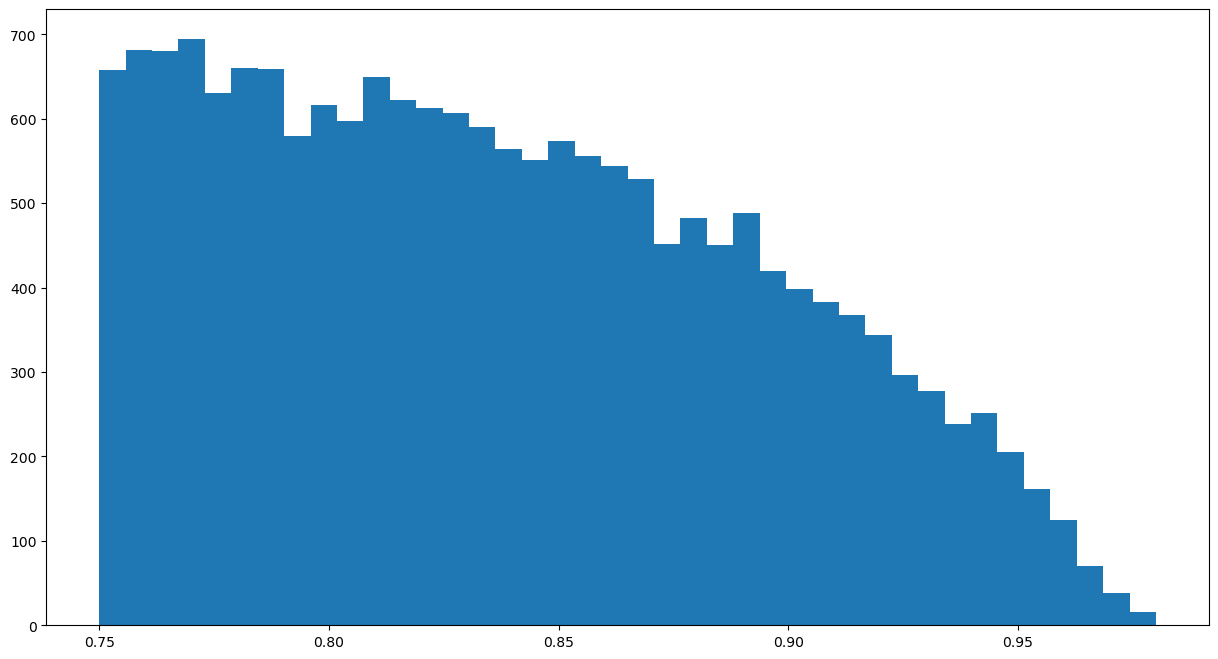

In [398]:
plt.hist(dfcut1['bdt_all'], bins=40)

,19,24,22,0,14,20,18,23,7,25,16,21,29,26,27,13,15,others
name,,,,,,,,,,,,,,,,,,
19,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.18,0.00,0.0,0.00,0.00,0.00,0.81,0.00,0.00
24,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.01,0.14,0.0,0.00,0.00,0.00,0.22,0.00,0.00
22,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.05,0.97,0.00,0.01,0.00
0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.0,0.00,0.00,0.00,0.00,0.12,0.00
14,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.16,0.00,0.0,0.00,0.00,0.00,0.35,0.00,0.00
20,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.09,0.00,0.00
18,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.0,0.18,0.00,0.00,0.00,0.00,0.00
23,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.08,0.00,0.63,0.10
7,0.06,0.03,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.19,0.00,0.0,0.00,0.00,0.00,0.61,0.00,0.00


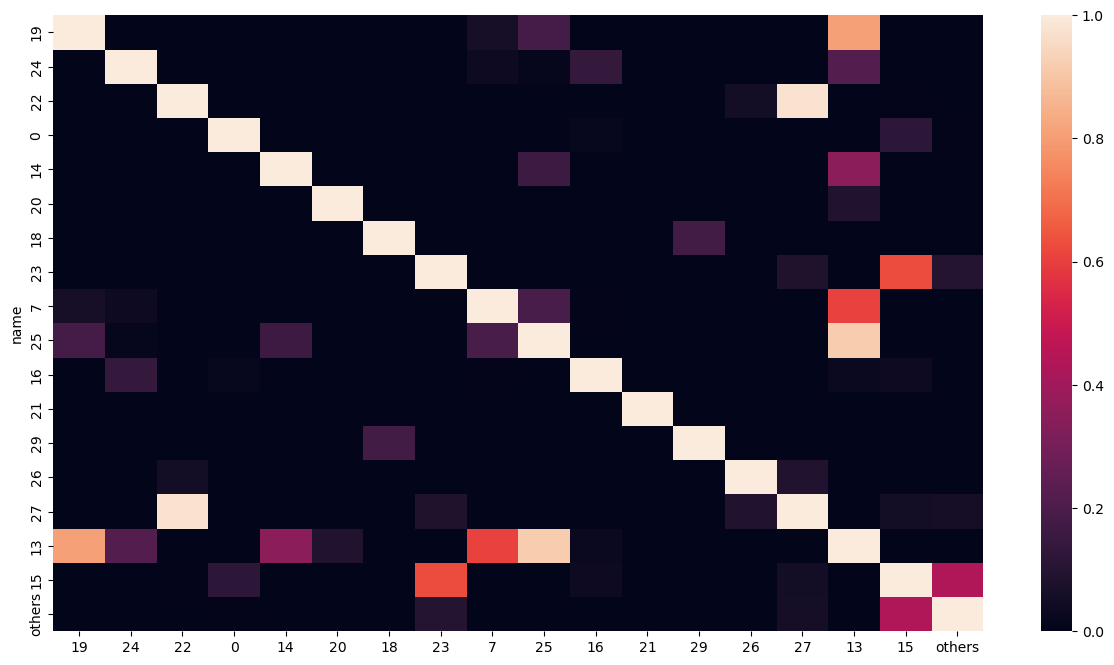

In [399]:
sq2_2cut1, stauY_2cut1, sbdt_allcut1 = similar_categories(dfcut1, 17)
plt.figure()
sn.heatmap(sq2_2cut1)
# plt.figure()
# sn.heatmap(stauY_2cut1)
# plt.figure()
# sn.heatmap(sbdt_allcut1);
sq2_2cut1.round(2)

In [402]:
pprint(find_and_merge_clusters(sq2_2cut1, 0.2))

[['22', '27'],
 ['20'],
 ['18'],
 ['29'],
 ['26'],
 ['0'],
 ['16'],
 ['21'],
 ['15', 'others', '23'],
 ['13', '7', '14', '24', '19', '25']]


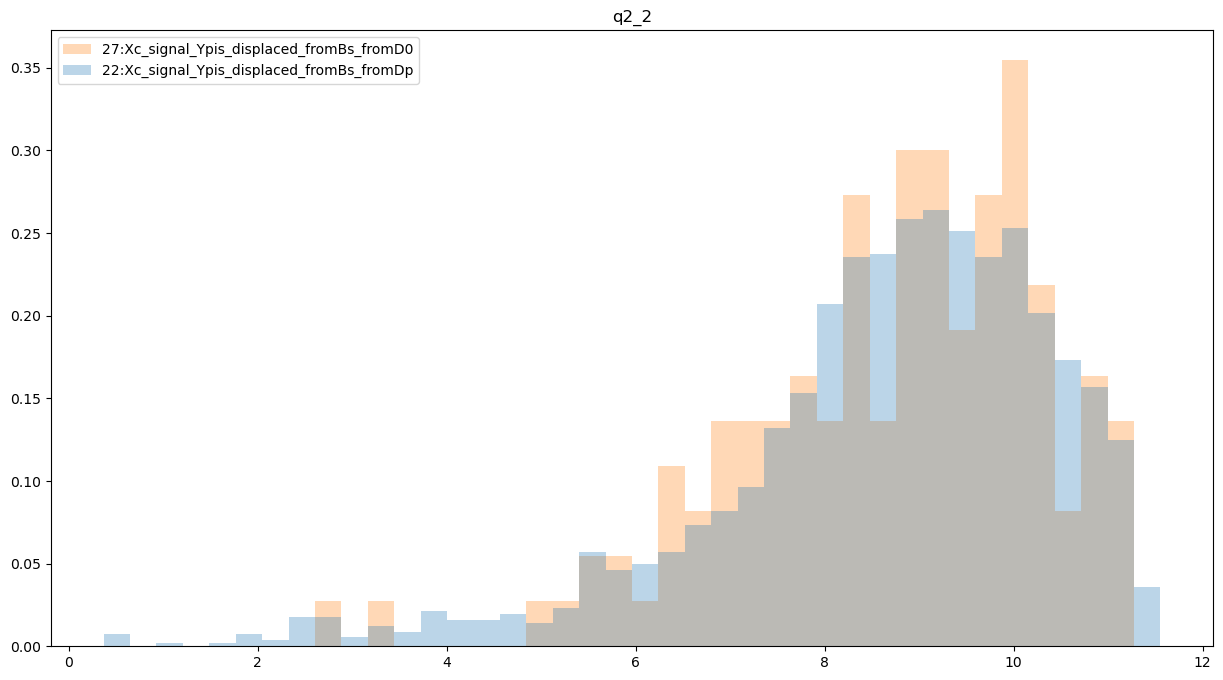

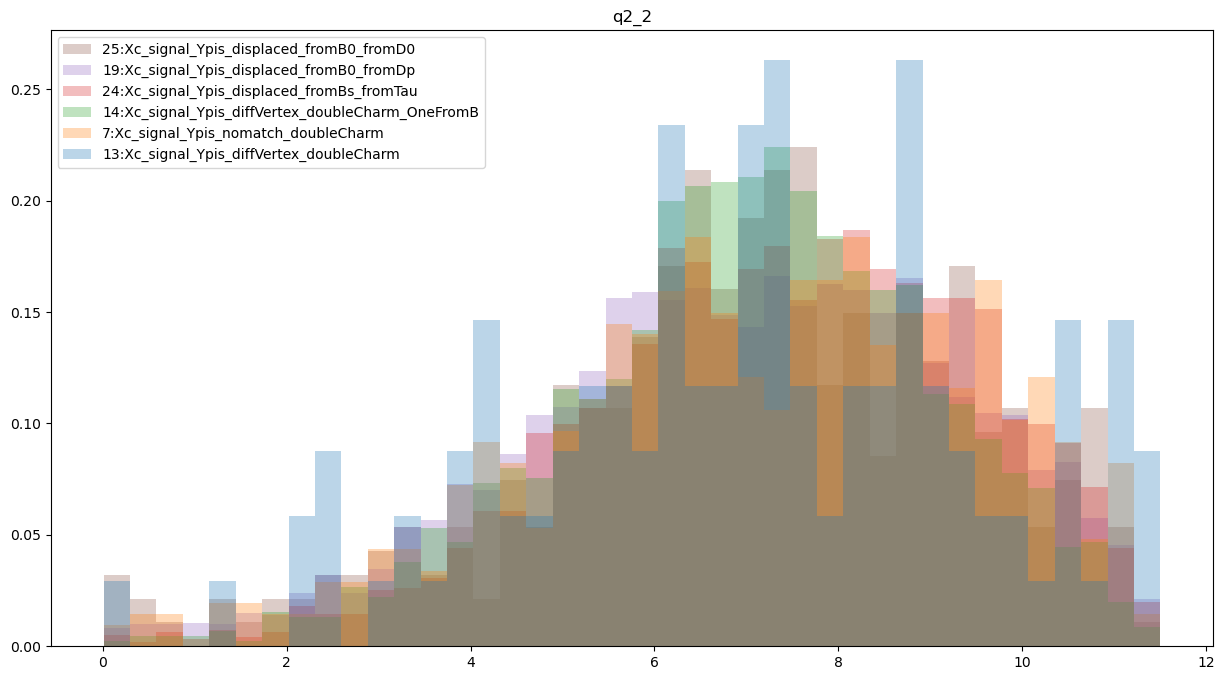

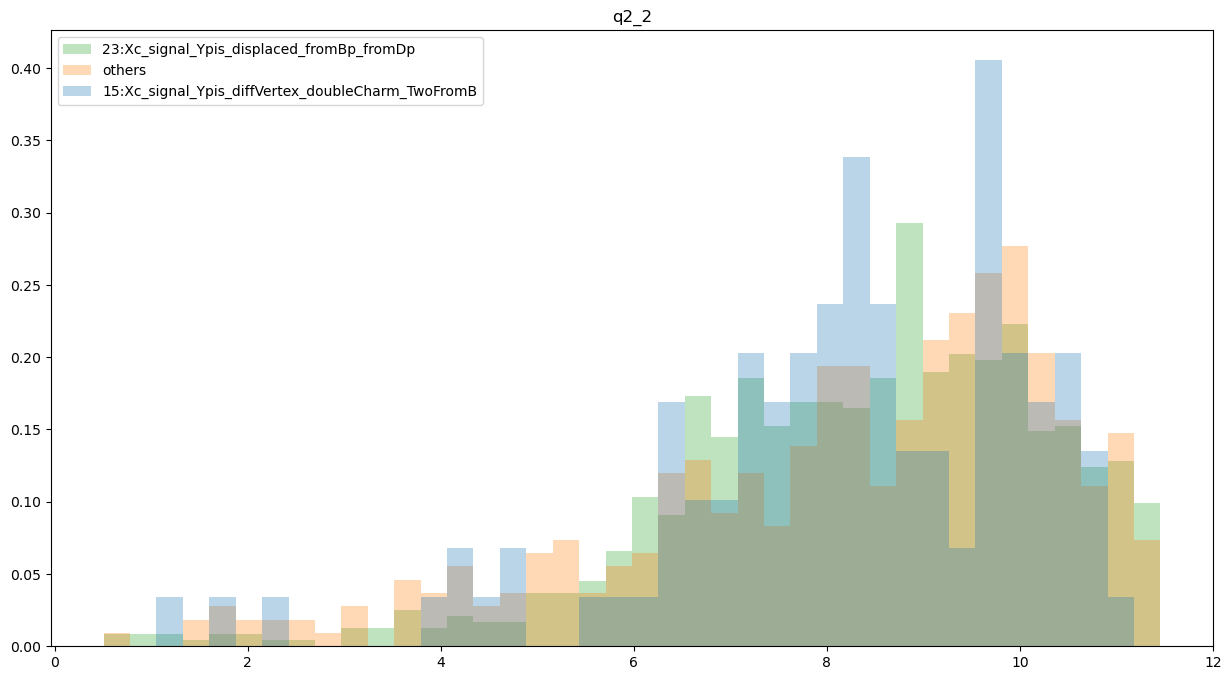

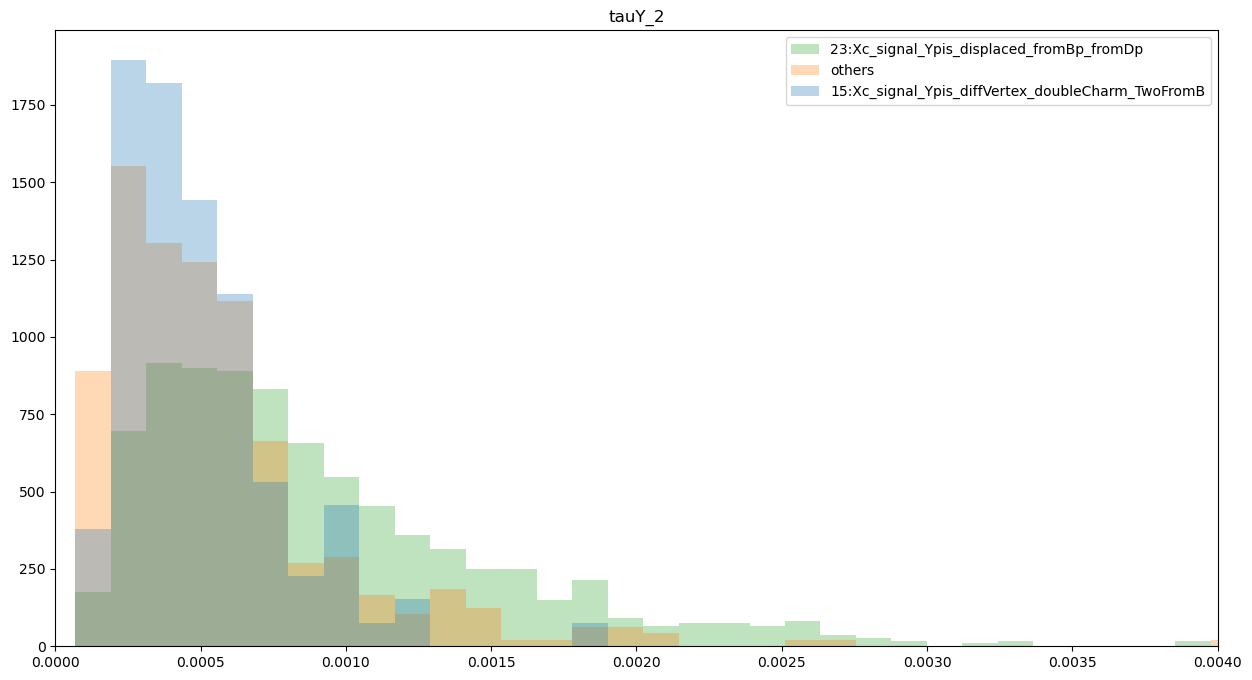

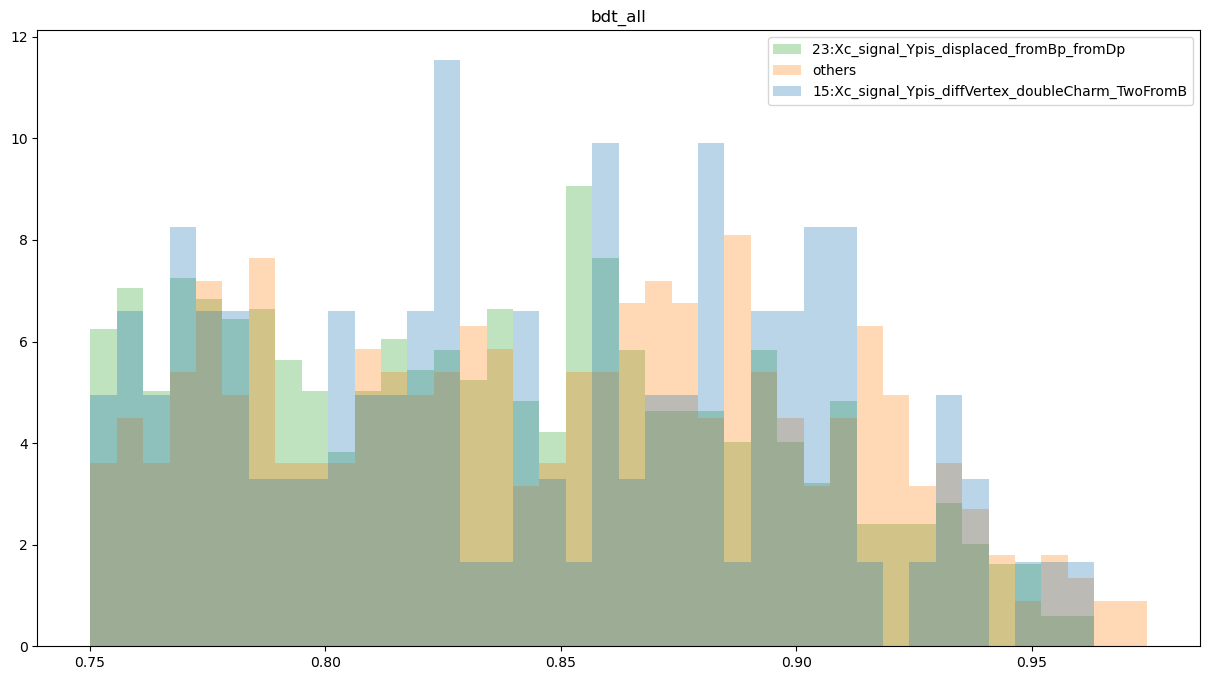

In [404]:
plot_templates_categs( ['22', '27'], "q2_2")
plt.figure()
plot_templates_categs(['13', '7', '14', '24', '19', '25'], "q2_2")
plt.figure()
plot_templates_categs(['15', 'others', '23'], "q2_2")
plt.figure()
plot_templates_categs(['15', 'others', '23'], "tauY_2")
plt.figure()
plot_templates_categs(['15', 'others', '23'], "bdt_all")

## Systematically comparing the projections

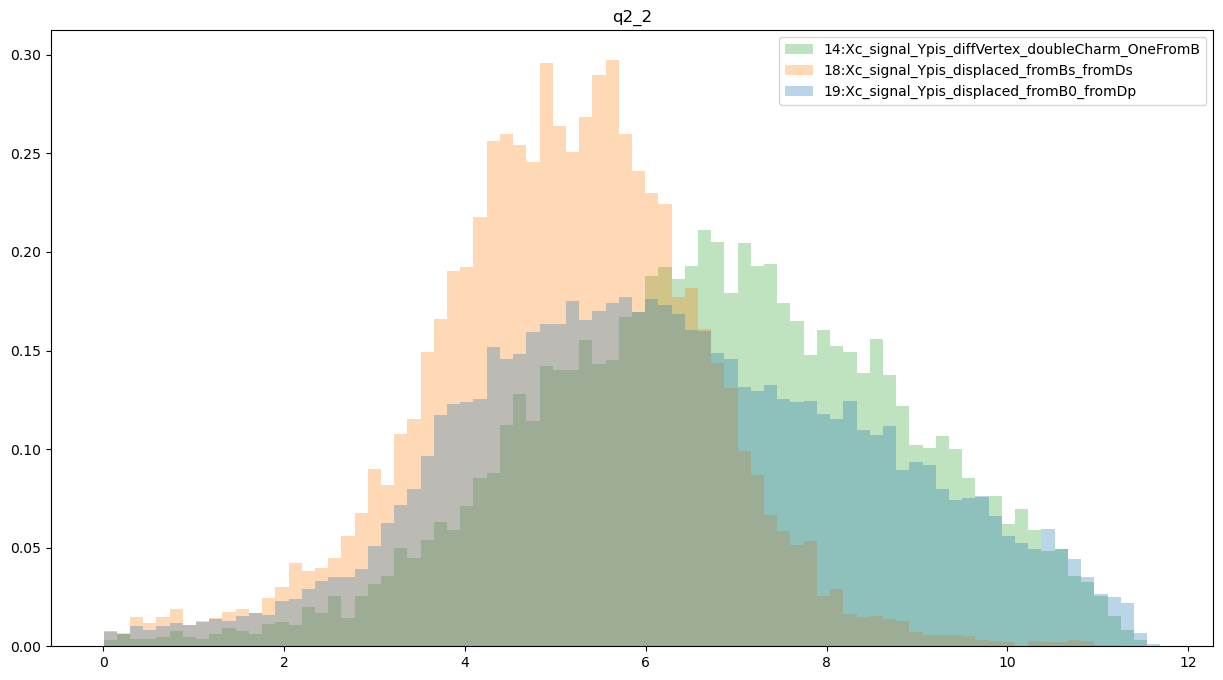

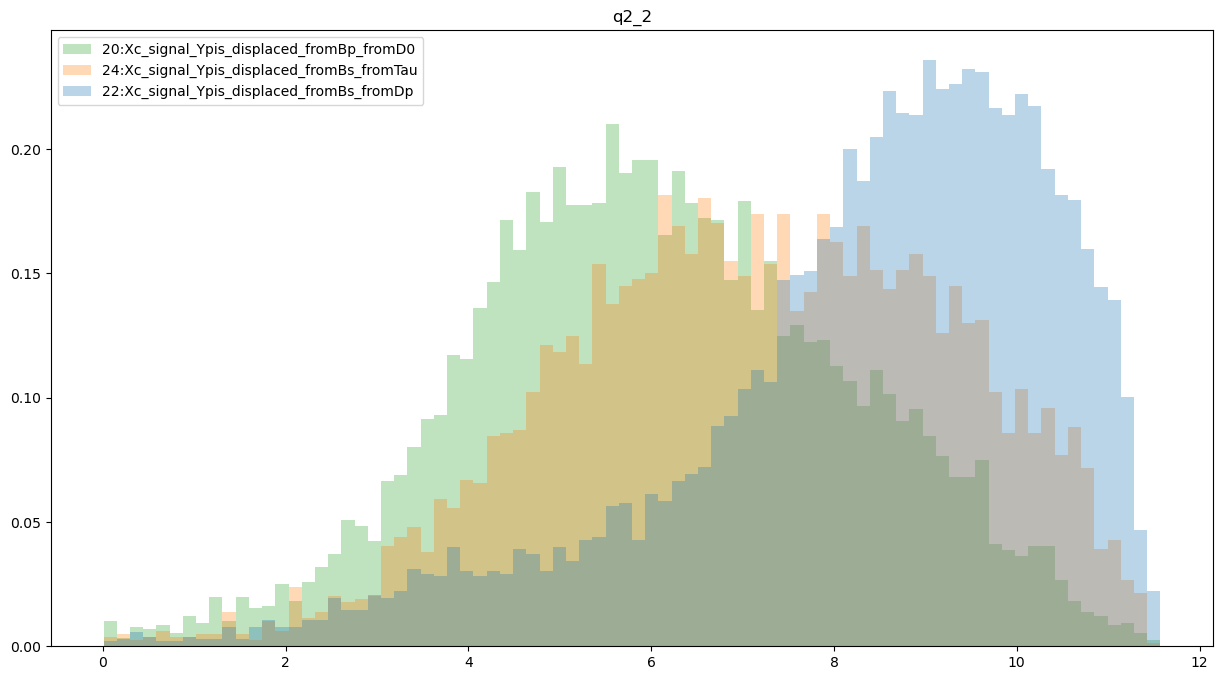

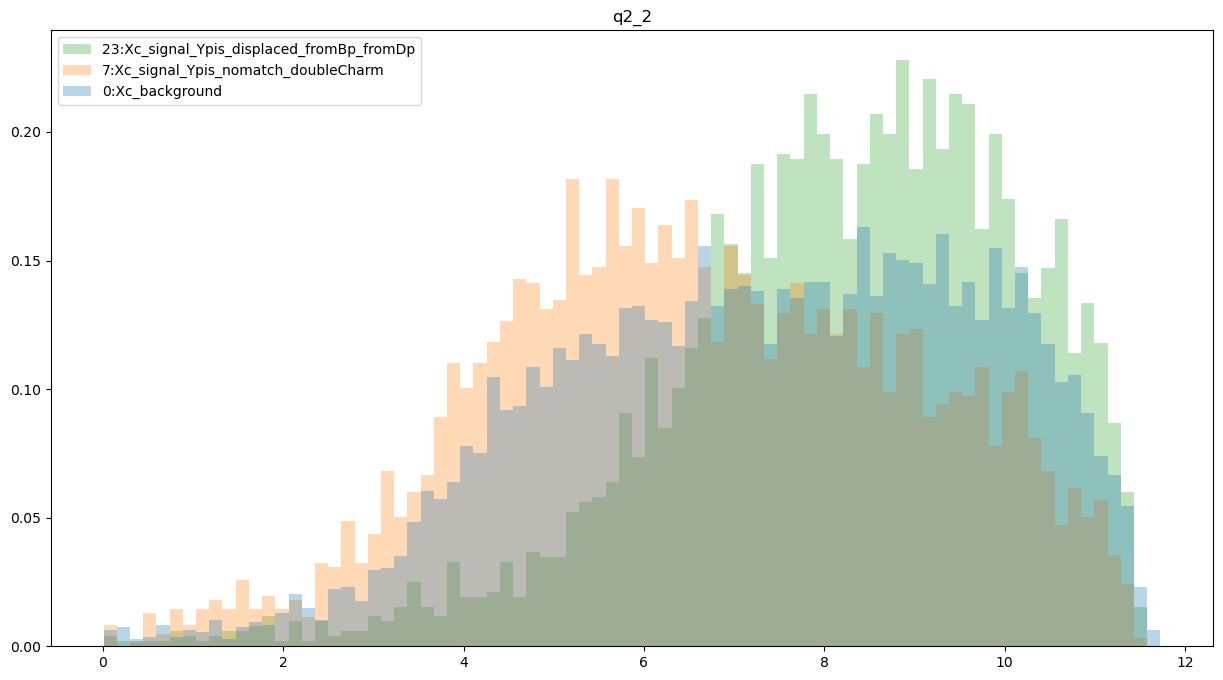

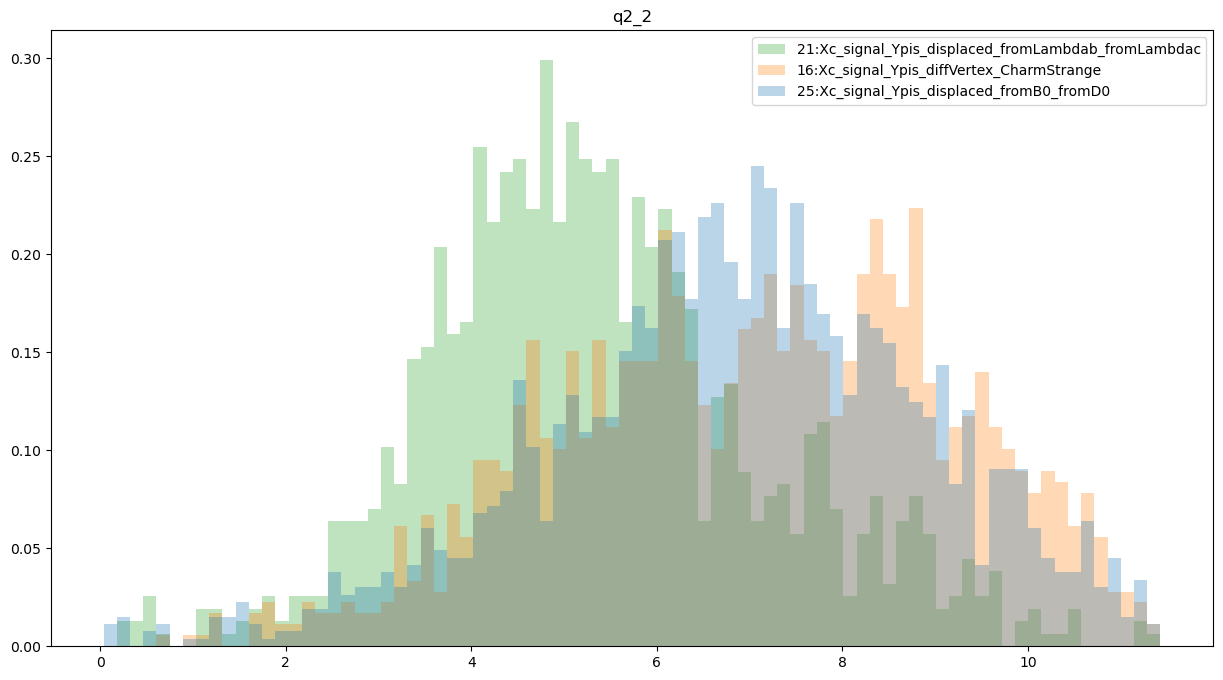

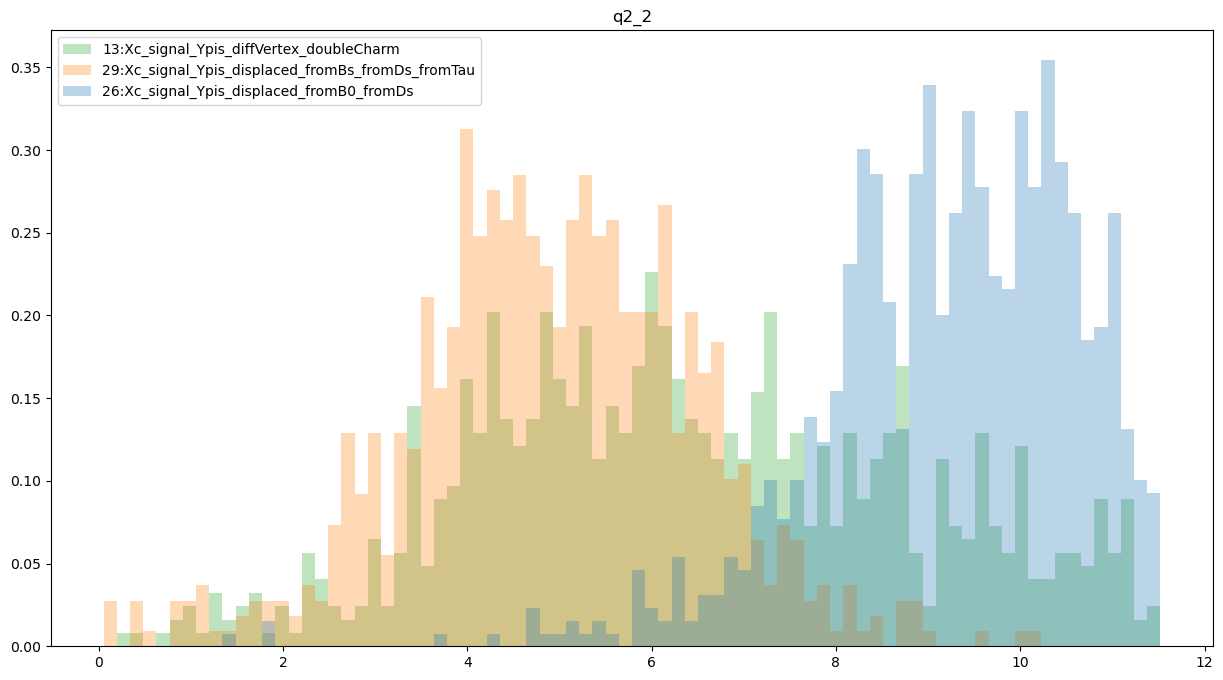

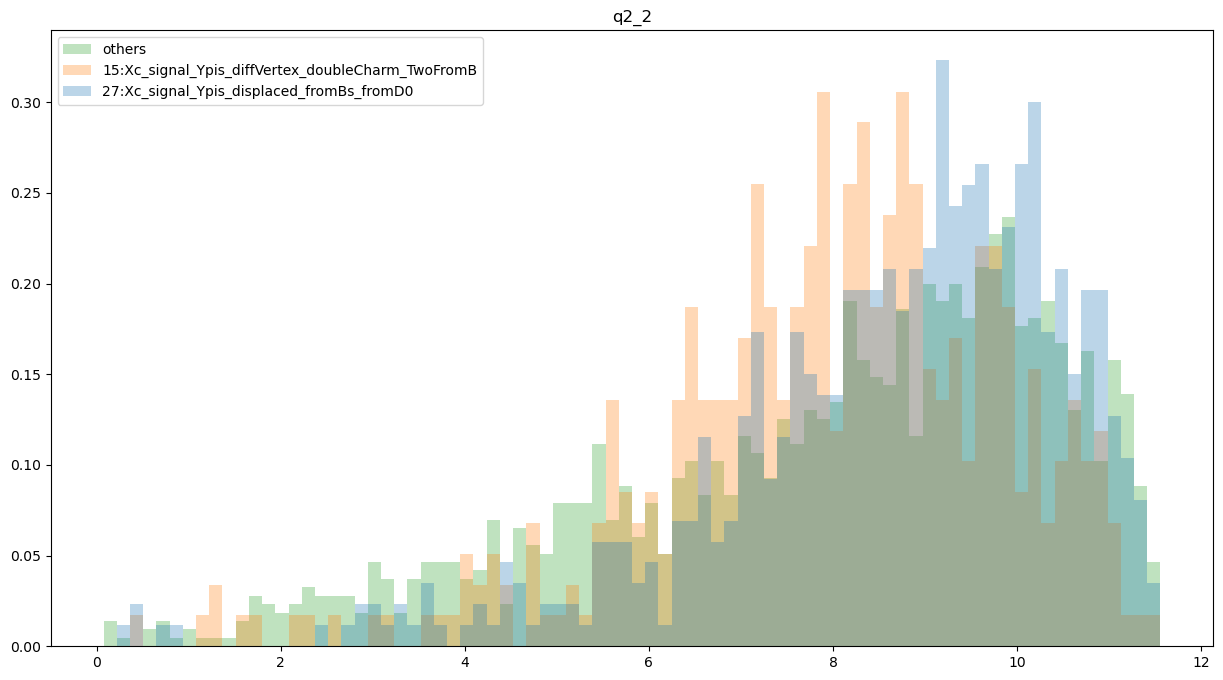

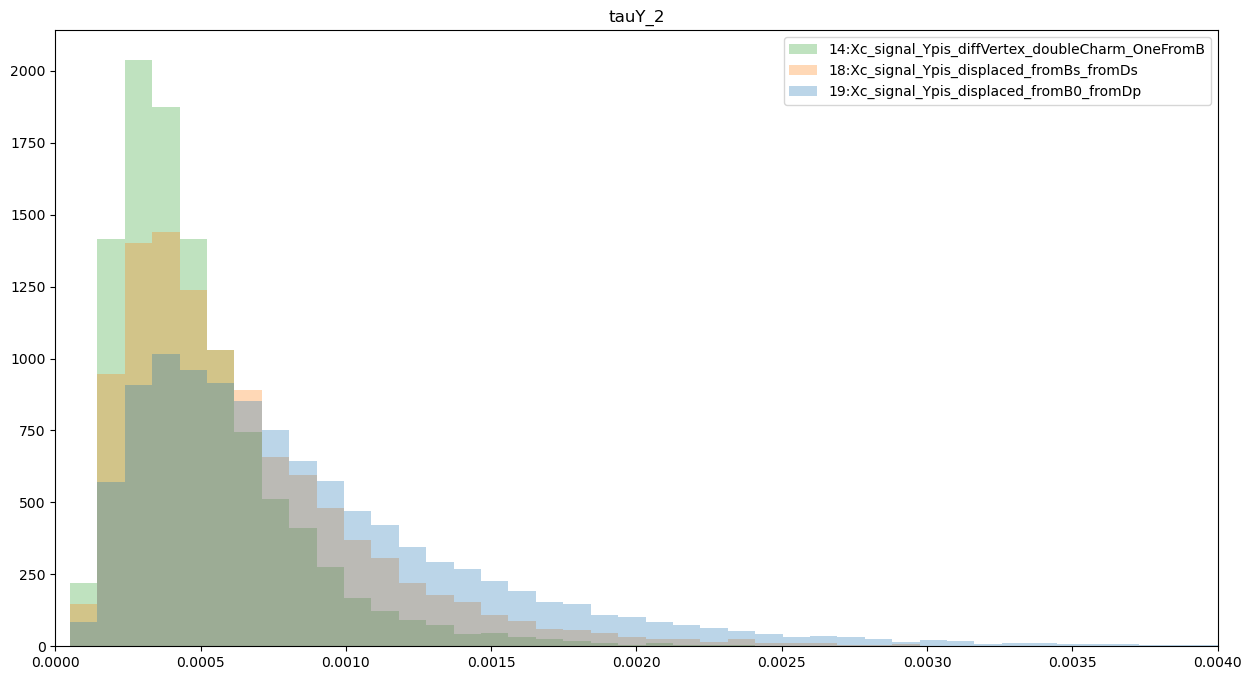

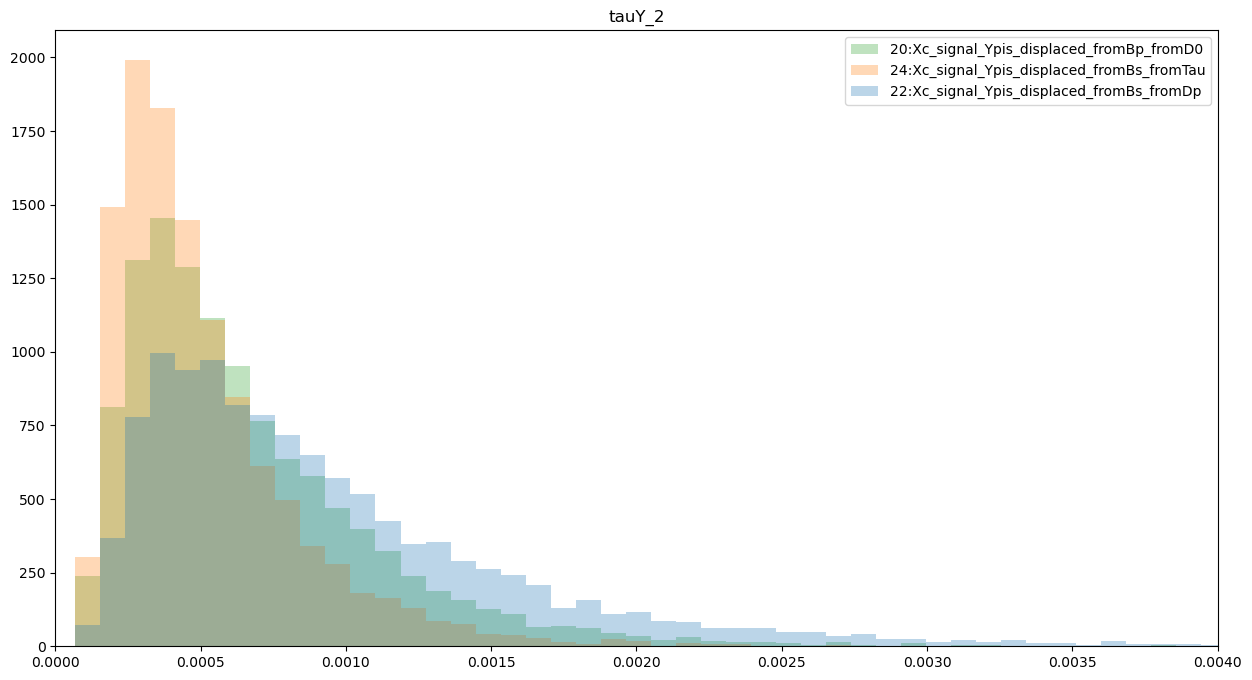

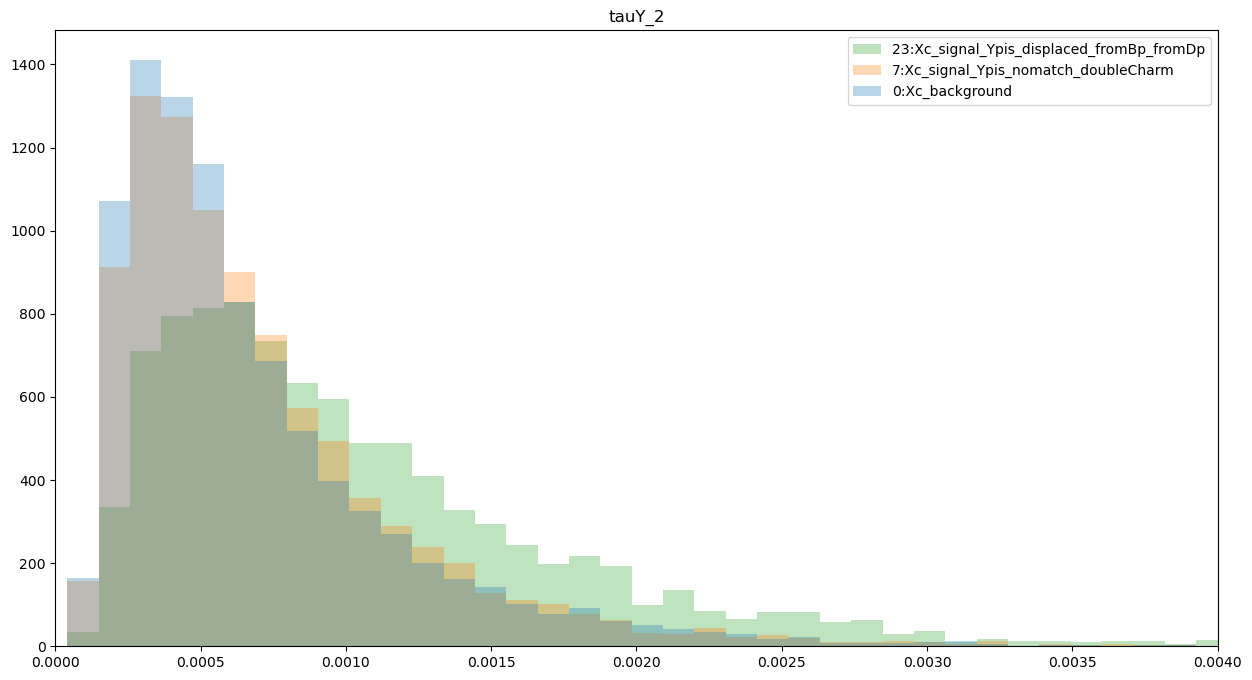

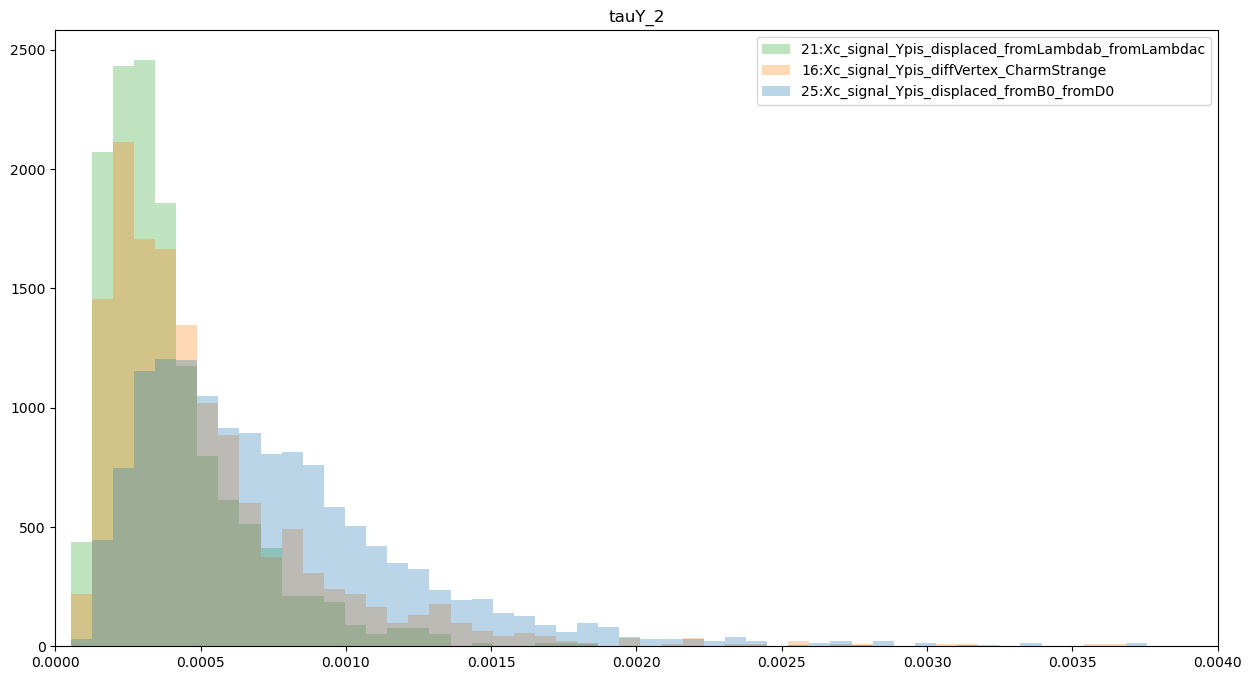

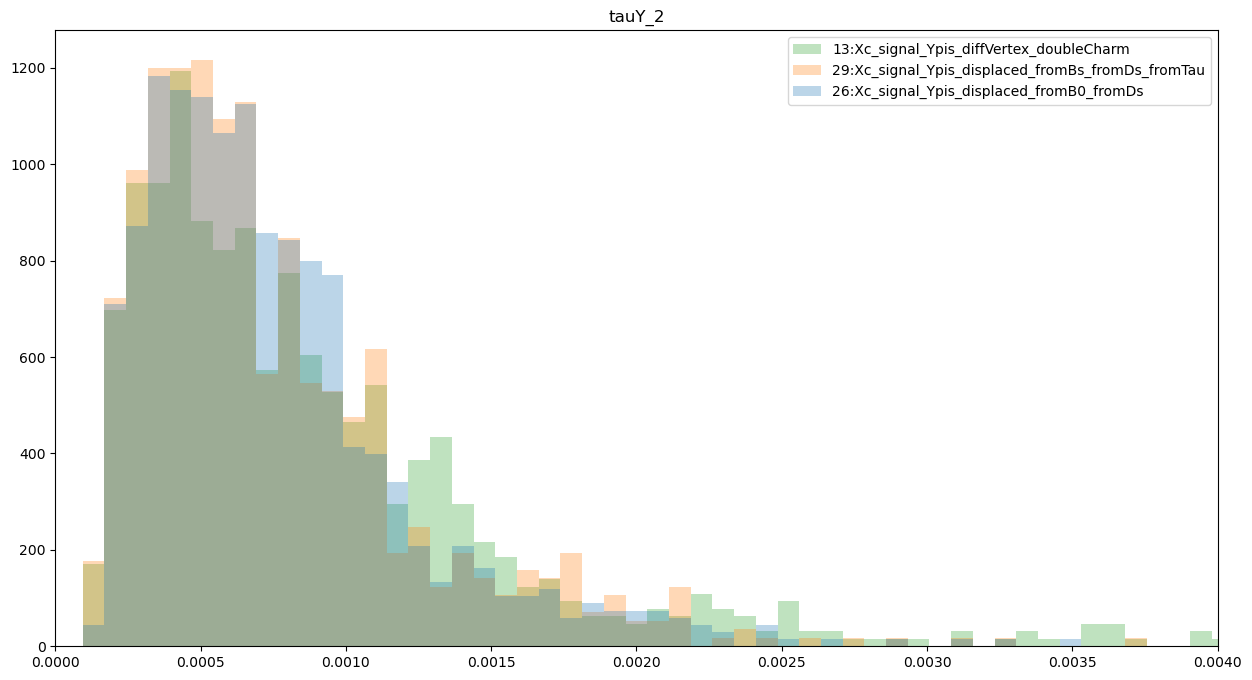

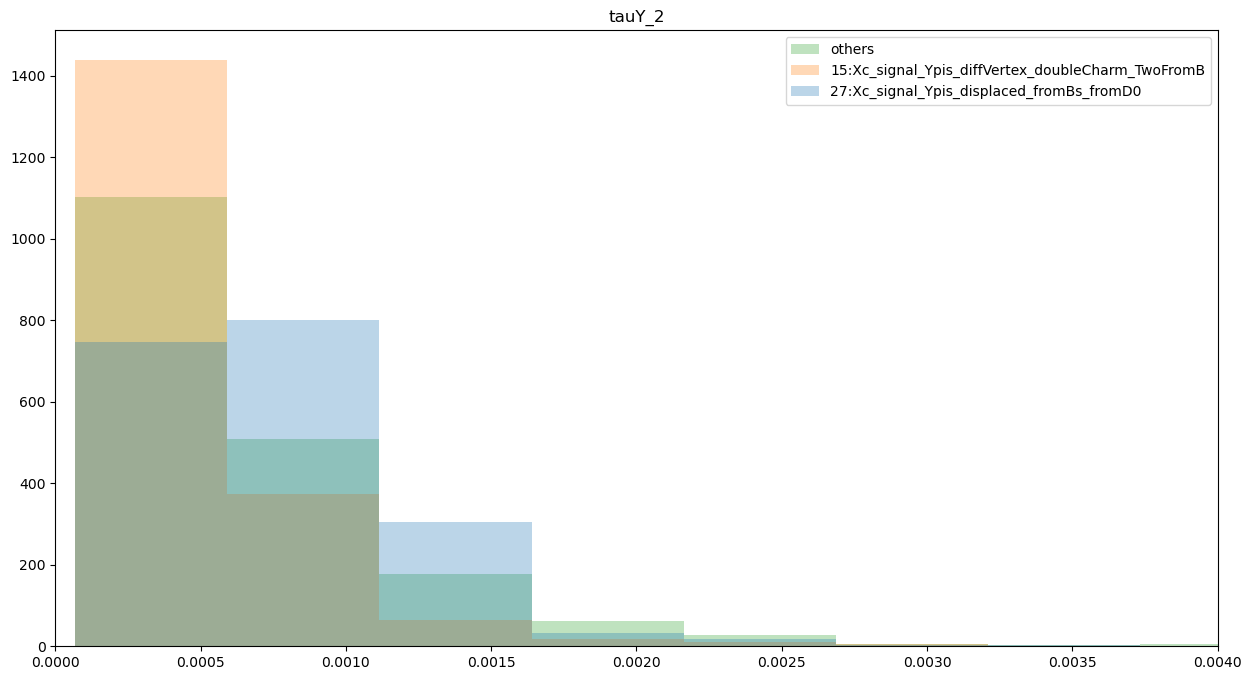

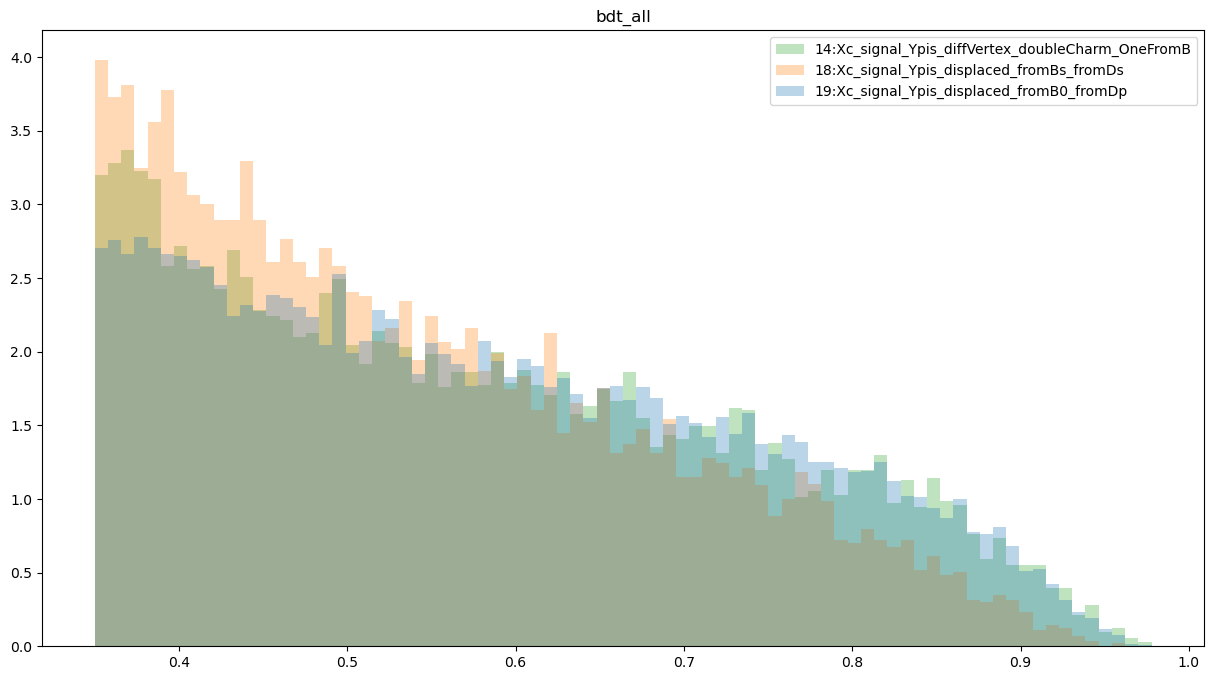

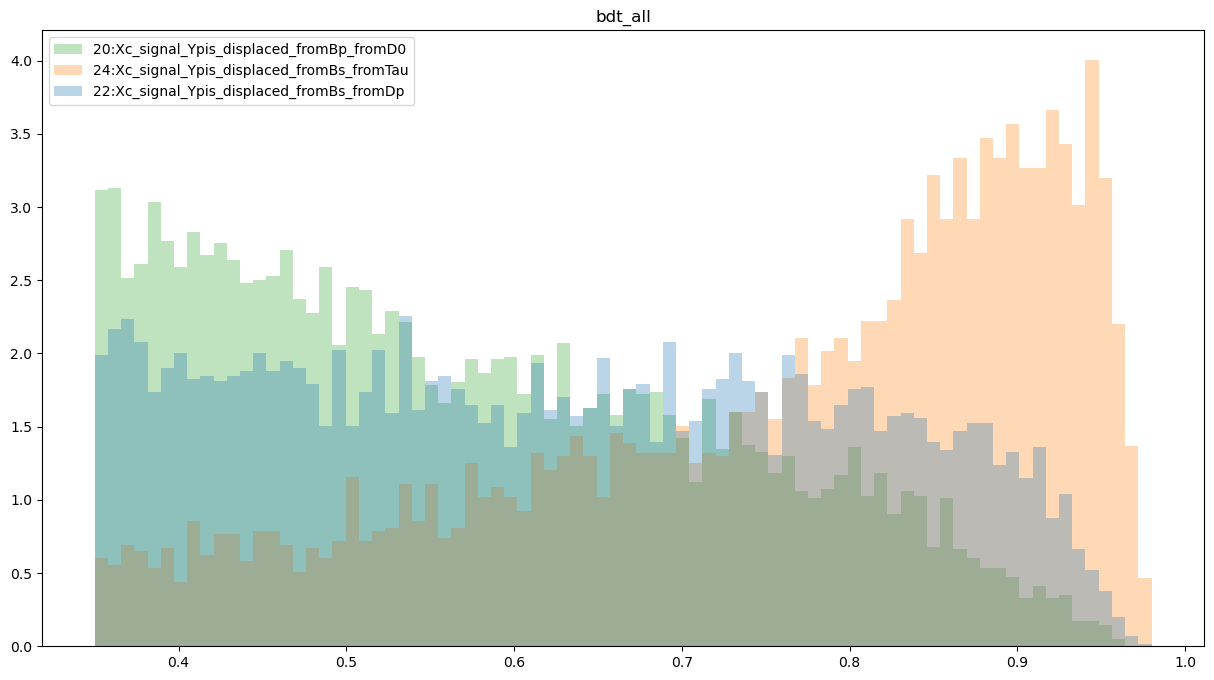

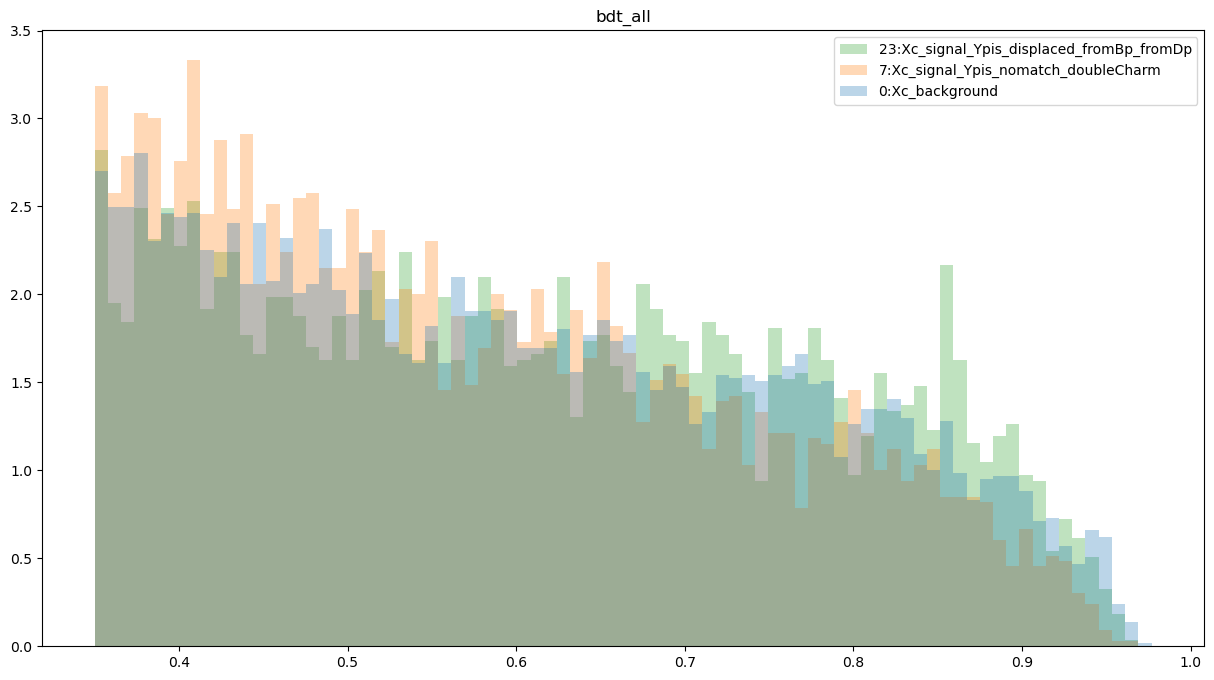

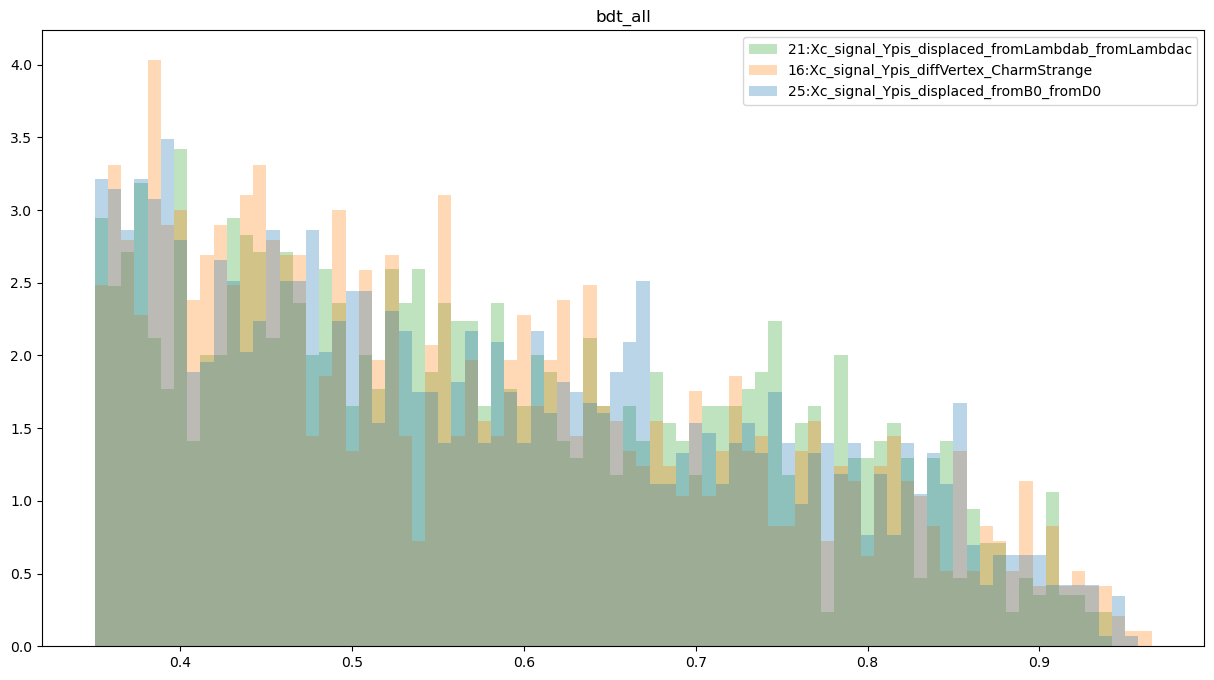

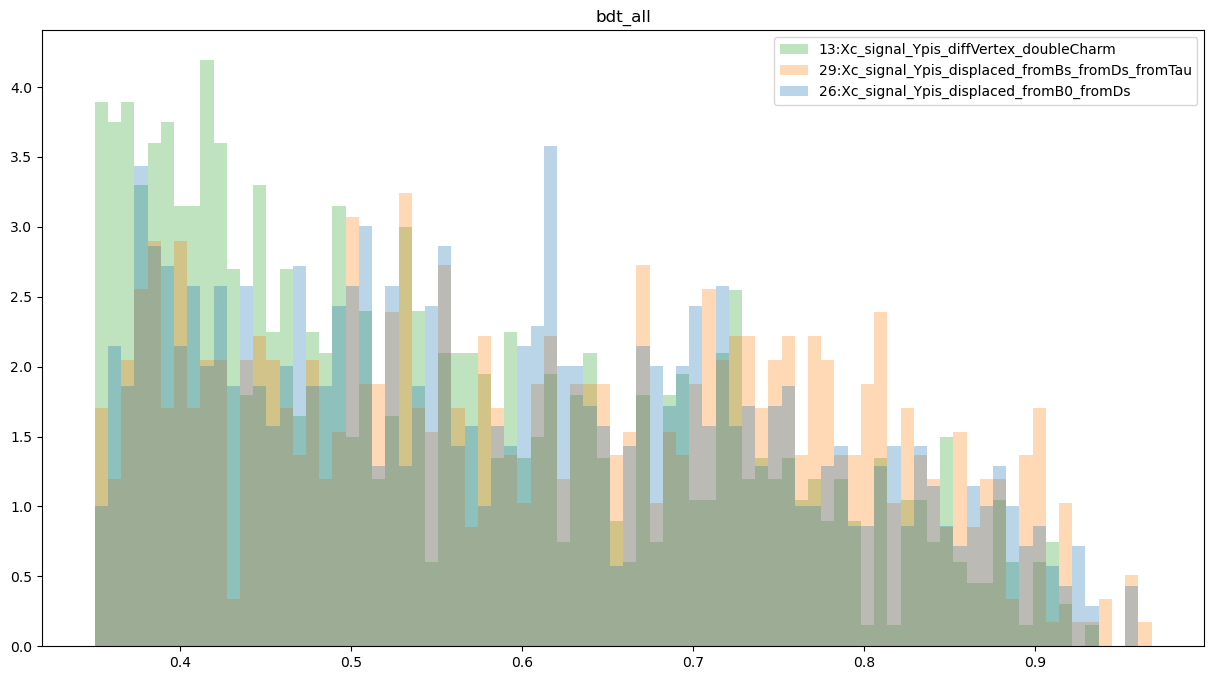

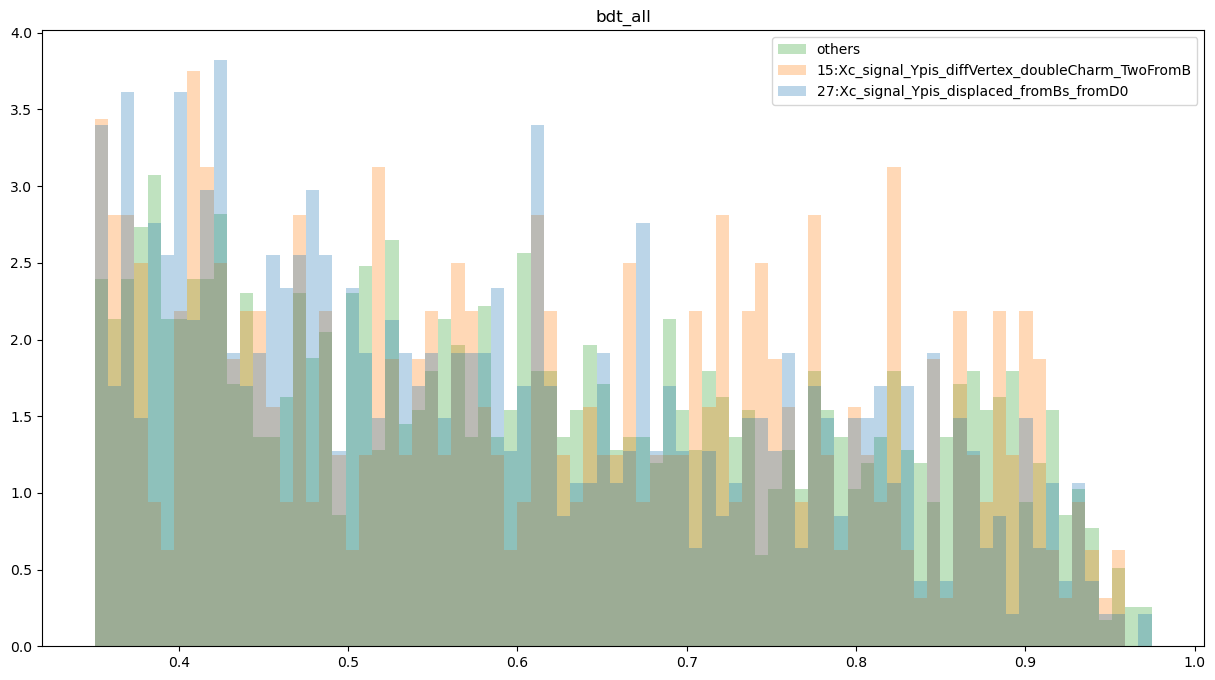

In [159]:


n_in_plot = 3
for i in range(0, len(datasets), n_in_plot):
    plt.figure()
    plot_templates(datasets[i:i+n_in_plot], datasets_names[i:i+n_in_plot], 'q2_2')

for i in range(0, len(datasets), n_in_plot):
    plt.figure()
    plot_templates(datasets[i:i+n_in_plot], datasets_names[i:i+n_in_plot], 'tauY_2')

for i in range(0, len(datasets), n_in_plot):
    plt.figure() 
    plot_templates(datasets[i:i+n_in_plot], datasets_names[i:i+n_in_plot], 'bdt_all')

## Checking CUT3 with bdt_all > 0.5

In [18]:
dfcut3 = df.query("bdt_all > 0.50")
c = mygroupby(dfcut3, 'category')
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c

,category,count,Percentage,cumulative %,name
0,19,13643,24.699024,24.699024,Xc_signal_Ypis_displaced_fromB0_fromDp
1,18,5634,10.199685,34.898709,Xc_signal_Ypis_displaced_fromBs_fromDs
2,14,5470,9.902783,44.801492,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB
3,22,5059,9.158716,53.960208,Xc_signal_Ypis_displaced_fromBs_fromDp
4,24,4940,8.943281,62.903489,Xc_signal_Ypis_displaced_fromBs_fromTau
5,20,4845,8.771295,71.674783,Xc_signal_Ypis_displaced_fromBp_fromD0
6,0,4794,8.678965,80.353748,Xc_background
7,7,2544,4.605609,84.959357,Xc_signal_Ypis_nomatch_doubleCharm
8,23,2430,4.399225,89.358582,Xc_signal_Ypis_displaced_fromBp_fromDp
9,25,1127,2.040299,91.398881,Xc_signal_Ypis_displaced_fromB0_fromD0


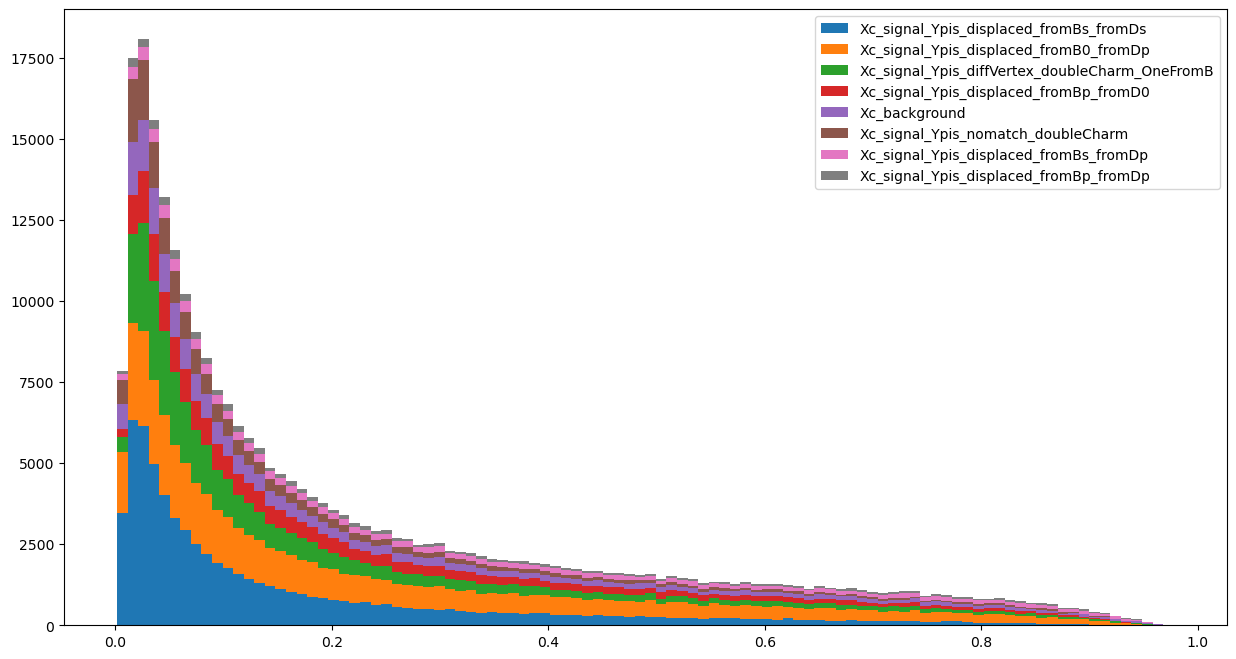

In [20]:
categories_toshow = list(mygroupby(df, 'category').head(8)['category'])
dfpercat = [df.query(f"category == {c}")['bdt_all'] for c in categories_toshow]
plt.hist(dfpercat, bins=100, label=[ categories[f"{c}"] for c in categories_toshow], stacked=True)
plt.legend();

## Plot the templates for CUT1

In [25]:
dfcut1['bdt_all']

29      0.775056
47      0.812740
49      0.825149
87      0.855690
205     0.759453
          ...   
3098    0.925554
3100    0.810016
3102    0.904515
3106    0.803628
3107    0.898667
Name: bdt_all, Length: 18324, dtype: float32